# FINAL Methodology Implementation

## Overview
In this notebook we'll conduct the full implementation of our final methodology. The steps are as follows:
1. Load Data
2. Preprocess Data
3. Create Baseline Features
4. Compute NLP Features
5. Pre-Compute TD-Combinations of Dataframes
6. Train-Validation-Test split (70, 20, 10)
7. Fit & Tune Ridge Regression on all TD combinations (only train set) and find top 5
8. Fit & Tune XGBoost on top 5 TD combinations (only train set) and find best one
9. Predict validation set using XGBoost and use that data to fine tune Decision Model
10. Use XGBoost and Decision model on test set

(The above steps need to be refined)


---
## Importing Required Libraries
This section imports all necessary libraries for running the analysis in this notebook

In [1]:
# Uncomment if this is the first time running the notebook
#!pip install -r requirements.txt

In [2]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
from tqdm import tqdm

# API libraries
import requests
import os
from dotenv import load_dotenv
from gpu_pipeline.telemetry import TelemetryLogger, ensure_disk_headroom

# NLP libraries
import umap
import torch
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from datasets import Dataset

# ML Libraries
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, RidgeClassifierCV
from sklearn.base import clone
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Parallelization libraries
from joblib import Parallel, delayed
from scipy import stats

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 🔧 Configuration Constants
Centralized configuration parameters to avoid magic numbers throughout the notebook.

In [3]:
# ============================================================================
# CONFIGURATION CONSTANTS
# ============================================================================

# === Time-based Constants ===
FORECAST_HORIZON_HOURS = 24  # Predict 24 hours ahead
HOURS_PER_DAY = 24
HOURS_PER_WEEK = 168  # 7 * 24
HOURS_PER_TWO_WEEKS = 336  # 14 * 24

# === Feature Engineering Parameters ===
DEFAULT_LOOKBACK_WINDOW = HOURS_PER_TWO_WEEKS  # 336 hours
DEFAULT_DECAY_LAMBDA = 0.05  # Time decay parameter
SPREAD_TARGET_DEADBAND = 5.0  # EUR/MWh band for the neutral class

# === Dataset Split Parameters ===
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1
RANDOM_STATE = 42

# TODO: Check implementation of the CV vs DEFAULT variables

# === Cross-validation Parameters ===
N_CV_SPLITS = 5
CV_MIN_TRAIN_SIZE = HOURS_PER_TWO_WEEKS  # Minimum 2 weeks for training
CV_STEP_SIZE_HOURS = 24  # Step size between CV folds

DEFAULT_EXPANDING_SPLITS = 4  # low number for quicker iteration during development
DEFAULT_EXPANDING_STEP = 12
DEFAULT_MIN_TRAIN_SIZE = 336  # two weeks of hourly observations

# === Model Training Parameters ===
DEFAULT_BATCH_SIZE = 32
DEFAULT_N_JOBS = -1  # Use all CPU cores

print("Configuration constants loaded:")
print(f"  Forecast horizon: {FORECAST_HORIZON_HOURS} hours")
print(f"  Lookback window: {DEFAULT_LOOKBACK_WINDOW} hours ({DEFAULT_LOOKBACK_WINDOW // 24} days)")
print(f"  Train/Val/Test split: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
print(f"  CV splits: {N_CV_SPLITS} (min train size: {CV_MIN_TRAIN_SIZE} hours)")
print(f"  Spread deadband: ±{SPREAD_TARGET_DEADBAND} EUR/MWh")


Configuration constants loaded:
  Forecast horizon: 24 hours
  Lookback window: 336 hours (14 days)
  Train/Val/Test split: 0.7/0.2/0.1
  CV splits: 5 (min train size: 336 hours)
  Spread deadband: ±5.0 EUR/MWh


## 🖥️ Device Detection Utilities
Centralized GPU/device detection to eliminate code duplication.

In [4]:
# ============================================================================
# CENTRALIZED GPU/DEVICE DETECTION UTILITIES
# ============================================================================

def detect_compute_device(task='general', verbose=True):
    """
    Detect optimal compute device and recommended batch size.
    
    Args:
        task: Type of task ('general', 'embeddings', 'training')
        verbose: Print device information
    
    Returns:
        dict with device info and optimal batch size
    """
    import torch
    import os
    
    cpu_cores = os.cpu_count() or 8
    default_jobs = max(1, cpu_cores - 2)
    device_info = {
        'device': 'cpu',
        'backend': 'cpu',
        'gpu_name': None,
        'gpu_memory_gb': 0,
        'optimal_batch_size': 32,
        'tree_method': 'hist',
        'predictor': 'auto',
        'n_jobs': default_jobs,
        'description': f'CPU-only ({cpu_cores} cores)',
        'lgbm_device': 'cpu',
    }
    
    # Check for CUDA (NVIDIA GPUs)
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        gpu_count = torch.cuda.device_count()
        
        device_info.update({
            'device': 'cuda',
            'backend': 'cuda',
            'gpu_name': gpu_name,
            'gpu_memory_gb': gpu_memory,
            'description': f'CUDA ({gpu_name})',
            'tree_method': 'gpu_hist',
            'predictor': 'gpu_predictor',
            'n_jobs': max(1, default_jobs // gpu_count),
            'lgbm_device': 'gpu',
        })
        
        # Adjust batch size based on GPU memory
        if gpu_memory >= 24:
            device_info['optimal_batch_size'] = 512
        elif gpu_memory >= 16:
            device_info['optimal_batch_size'] = 384
        elif gpu_memory >= 8:
            device_info['optimal_batch_size'] = 256
        else:
            device_info['optimal_batch_size'] = 128
        
        if verbose:
            print(f"✓ CUDA detected: {gpu_name} ({gpu_memory:.1f} GB)")
            print(f"  Optimal batch size: {device_info['optimal_batch_size']}")
            print(f"  XGBoost tree method: {device_info['tree_method']} • predictor: {device_info['predictor']}")
            print(f"  Parallel jobs: {device_info['n_jobs']}")
    
    # Check for MPS (Apple Silicon)
    elif torch.backends.mps.is_available():
        device_info.update({
            'device': 'mps',
            'backend': 'mps',
            'gpu_name': 'Apple Silicon GPU',
            'optimal_batch_size': 128,
            'description': 'Apple MPS GPU',
            'tree_method': 'hist',
            'predictor': 'auto',
            'n_jobs': default_jobs,
            'lgbm_device': 'cpu',
        })
        
        if verbose:
            print("✓ MPS detected: Apple Silicon GPU")
            print(f"  Optimal batch size: {device_info['optimal_batch_size']}")
            print("  XGBoost will fallback to CPU histogram (MPS unsupported)")
    
    else:
        if verbose:
            print("⚠ No GPU detected, using CPU")
            print(f"  Optimal batch size: {device_info['optimal_batch_size']}")
            print(f"  Parallel jobs: {device_info['n_jobs']}")
    
    return device_info


# Test the function
device_config = detect_compute_device(task='general', verbose=True)


✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)


In [5]:
# ============================================================================
# STAGE PROFILING UTILITIES
# ============================================================================

import time
from contextlib import AbstractContextManager

try:
    import psutil
except Exception:  # pragma: no cover - psutil not required at runtime
    psutil = None

try:
    import pynvml
    pynvml.nvmlInit()
    _NVML_AVAILABLE = True
except Exception:
    _NVML_AVAILABLE = False


def _read_gpu_state():
    if not _NVML_AVAILABLE:
        return None
    try:
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)
        util = pynvml.nvmlDeviceGetUtilizationRates(handle)
        memory = pynvml.nvmlDeviceGetMemoryInfo(handle)
        return {
            "gpu_util": util.gpu,
            "mem_util": util.memory,
            "mem_used_gb": memory.used / (1024 ** 3),
            "mem_total_gb": memory.total / (1024 ** 3),
        }
    except Exception:
        return None


def _read_cpu_state():
    if psutil is None:
        return None
    cpu_times = psutil.cpu_times_percent(interval=None)
    disk_io = psutil.disk_io_counters() if hasattr(psutil, "disk_io_counters") else None
    return {
        "cpu_percent": psutil.cpu_percent(interval=None),
        "iowait_percent": getattr(cpu_times, "iowait", 0.0),
        "disk_read_mb": (disk_io.read_bytes / (1024 ** 2)) if disk_io else None,
        "disk_write_mb": (disk_io.write_bytes / (1024 ** 2)) if disk_io else None,
    }


class StageProfiler(AbstractContextManager):
    """Context manager to capture per-stage resource consumption."""

    def __init__(self, stage_name: str, device_config: dict | None = None):
        self.stage_name = stage_name
        self.device_config = device_config or {}
        self._start_time = None
        self._start_cpu = None
        self._start_gpu = None

    def __enter__(self):
        print(f"\n[Stage ⏳] {self.stage_name} — starting")
        self._start_time = time.time()
        self._start_cpu = _read_cpu_state()
        self._start_gpu = _read_gpu_state()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        end_time = time.time()
        end_cpu = _read_cpu_state()
        end_gpu = _read_gpu_state()
        duration = end_time - (self._start_time or end_time)

        metrics: dict[str, float | int | None] = {
            "duration_sec": duration,
        }

        print(f"[Stage ✅] {self.stage_name} — completed in {duration:.2f}s")

        if end_cpu:
            cpu_percent = end_cpu.get("cpu_percent")
            iowait_percent = end_cpu.get("iowait_percent")
            metrics.update({
                "cpu_percent": cpu_percent,
                "cpu_iowait_percent": iowait_percent,
            })
            if cpu_percent is not None:
                print(f"  CPU usage: {cpu_percent:.1f}% • IO wait: {iowait_percent:.2f}%")
            if self._start_cpu and end_cpu:
                read_delta = end_cpu.get("disk_read_mb")
                write_delta = end_cpu.get("disk_write_mb")
                start_read = self._start_cpu.get("disk_read_mb", 0.0) if self._start_cpu else 0.0
                start_write = self._start_cpu.get("disk_write_mb", 0.0) if self._start_cpu else 0.0
                if read_delta is not None and write_delta is not None:
                    read_mb = max(0.0, read_delta - start_read)
                    write_mb = max(0.0, write_delta - start_write)
                    metrics.update({
                        "disk_read_mb": read_mb,
                        "disk_write_mb": write_mb,
                    })
                    print(f"  Disk Δ: +{read_mb:.1f} MB read, +{write_mb:.1f} MB written")

        if end_gpu:
            metrics.update(
                {
                    "gpu_util_percent": end_gpu.get("gpu_util"),
                    "gpu_mem_util_percent": end_gpu.get("mem_util"),
                    "gpu_mem_used_gb": end_gpu.get("mem_used_gb"),
                    "gpu_mem_total_gb": end_gpu.get("mem_total_gb"),
                }
            )
            print(
                "  GPU util: {gpu_util:.0f}% • Mem util: {mem_util:.0f}% "
                "({mem_used_gb:.2f}/{mem_total_gb:.2f} GB)".format(**end_gpu)
            )
        elif self.device_config.get("device") in {"cuda", "mps"}:
            print("  GPU metrics unavailable (install pynvml for CUDA visibility)")

        telemetry_logger = globals().get('telemetry_logger')
        if telemetry_logger is not None:
            try:
                telemetry_logger.log_stage(self.stage_name, metrics)
            except Exception as logging_exc:  # pragma: no cover - telemetry must not break execution
                print(f"  ⚠️ Telemetry logging failed: {logging_exc}")

        return False  # propagate exceptions


In [6]:
telemetry_logger = TelemetryLogger(
    metadata={
        "random_state": str(RANDOM_STATE),
        "notebook": "final_methodology/final_v2.ipynb",
        "device": device_config.get("description"),
    }
)
ensure_disk_headroom(Path('.'), min_free_gb=5.0)
print(f"Telemetry logging to {telemetry_logger.log_dir}")


Telemetry logging to /Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology/logs/telemetry


In [7]:
# ==========================================================================
# CENTRAL DEVICE REGISTRY
# ==========================================================================

PRIMARY_DEVICE = device_config.get("device", "cpu")
PRIMARY_TORCH_DEVICE = torch.device("cuda" if PRIMARY_DEVICE == "cuda" else PRIMARY_DEVICE)

if PRIMARY_DEVICE == "cuda" and torch.cuda.is_available():
    torch.cuda.set_device(0)
    torch.cuda.empty_cache()
    torch.set_default_tensor_type(torch.cuda.FloatTensor)
elif PRIMARY_DEVICE == "mps" and torch.backends.mps.is_available():
    if hasattr(torch, "mps") and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()
    if hasattr(torch, "set_default_device"):
        torch.set_default_device("mps")

print(f"Primary compute device: {PRIMARY_DEVICE}")


def ensure_tensor_device(obj):
    """Move torch tensors (or collections thereof) onto the primary device."""
    if torch.is_tensor(obj):
        return obj.to(PRIMARY_TORCH_DEVICE)
    if isinstance(obj, (list, tuple)):
        return type(obj)(ensure_tensor_device(x) for x in obj)
    if isinstance(obj, dict):
        return {k: ensure_tensor_device(v) for k, v in obj.items()}
    return obj


def resolve_hf_device(primary_device: str):
    if primary_device == "cuda" and torch.cuda.is_available():
        return 0
    if primary_device == "mps" and torch.backends.mps.is_available():
        return "mps"
    return -1


Primary compute device: mps


In [8]:
# ============================================================================
# FEATURE IMPORTANCE ANALYSIS FUNCTION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(model, feature_names, model_name, top_n=20):
    """Plot LightGBM feature importance (gain) for a fitted model."""
    if not hasattr(model, "feature_importances_"):
        print(f"{model_name} does not expose feature_importances_.")
        return None

    importances = model.feature_importances_
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Feature name count ({len(feature_names)}) does not match model importances "
            f"({len(importances)}). Ensure feature_names reflects the training columns."
        )

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    top_df = importance_df.head(top_n)

    plt.figure(figsize=(10, max(6, len(top_df) * 0.4)))
    sns.barplot(
        data=top_df,
        x="importance",
        y="feature",
        palette="Blues_r"
    )
    plt.title(f"{model_name} – Top {len(top_df)} Features (Gain)")
    plt.xlabel("Importance (Gain)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    return importance_df

In [9]:
# ==========================================================================
# GLOBAL CV DEFAULTS
# ==========================================================================

DEFAULT_EXPANDING_SPLITS = 4  # low number for quicker iteration during development
DEFAULT_EXPANDING_STEP = 12
DEFAULT_MIN_TRAIN_SIZE = 336  # two weeks of hourly observations



In [10]:
# ============================================================================
# CONFUSION MATRIX VISUALIZATION FUNCTION
# ============================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrices(models_dict, y_test, class_labels, label_encoder=None):
    """
    Plot confusion matrices for multiple models.

    models_dict: dict[str, tuple[sklearn estimator, pd.DataFrame or np.ndarray]]
        Mapping from model name to (fitted estimator, feature matrix) pair.
    y_test: pd.Series or np.ndarray
        Ground-truth labels (already aligned with all feature matrices).
    class_labels: list
        Class labels to keep fixed across plots.
    label_encoder: Optional[LabelEncoder]
        If provided, predictions produced by the estimators will be inverse-transformed
        into the original label space before computing the confusion matrix.
    """
    y_true = np.asarray(y_test)
    n_models = len(models_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), squeeze=False)
    axes = axes.ravel()

    for ax, (name, (model, X_test)) in zip(axes, models_dict.items()):
        y_pred = model.predict(X_test)
        if label_encoder is not None:
            y_pred = label_encoder.inverse_transform(y_pred)
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
        disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
        ax.set_title(name)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')

    plt.tight_layout()
    plt.show()

In [11]:
# ============================================================================
# STATISTICAL SIGNIFICANCE TESTING FUNCTIONS
# ============================================================================

from scipy import stats
import numpy as np
from sklearn.metrics import accuracy_score

def bootstrap_confidence_interval(y_true, y_pred_proba, metric_func, 
                                   n_bootstrap=1000, confidence=0.95, random_state=42):
    """
    Calculate bootstrap confidence interval for a metric.
    
    Args:
        y_true: True labels
        y_pred_proba: Predicted probabilities or predictions
        metric_func: Function to calculate metric (takes y_true, y_pred as input)
        n_bootstrap: Number of bootstrap iterations
        confidence: Confidence level (e.g., 0.95 for 95% CI)
        random_state: Random seed for reproducibility
    
    Returns:
        (mean, lower_bound, upper_bound)
    """
    np.random.seed(random_state)
    scores = []
    n_samples = len(y_true)
    
    for _ in range(n_bootstrap):
        # Sample with replacement
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        y_true_boot = y_true[indices] if isinstance(y_true, np.ndarray) else y_true.iloc[indices]
        y_pred_boot = y_pred_proba[indices] if isinstance(y_pred_proba, np.ndarray) else y_pred_proba.iloc[indices]
        
        try:
            score = metric_func(y_true_boot, y_pred_boot)
            if not np.isnan(score):
                scores.append(score)
        except Exception as e:
            continue
    
    if len(scores) == 0:
        return np.nan, np.nan, np.nan
    
    # Calculate percentile-based confidence interval
    alpha = (1 - confidence) / 2
    lower = np.percentile(scores, alpha * 100)
    upper = np.percentile(scores, (1 - alpha) * 100)
    
    return np.mean(scores), lower, upper


def compare_models_statistically(y_test, signal_pred, baseline_pred, 
                                signal_proba=None, baseline_proba=None):
    """
    Perform statistical comparison between signal and baseline models.
    
    Args:
        y_test: True test labels
        signal_pred: Signal model predictions (class labels)
        baseline_pred: Baseline model predictions (class labels)
        signal_proba: Signal model probability predictions (optional)
        baseline_proba: Baseline model probability predictions (optional)
    
    Returns:
        Dictionary with test results
    """
    print(f"\n{'='*70}")
    print("STATISTICAL MODEL COMPARISON")
    print(f"{'='*70}\n")

    # Convert to numpy arrays and validate shapes
    y_test_array = np.asarray(y_test)
    signal_pred_array = np.asarray(signal_pred)
    baseline_pred_array = np.asarray(baseline_pred)

    if y_test_array.shape != signal_pred_array.shape or y_test_array.shape != baseline_pred_array.shape:
        raise ValueError("Predictions and ground-truth labels must have identical shapes for statistical comparison.")

    observed_labels = np.unique(y_test_array)
    unexpected_signal = np.setdiff1d(np.unique(signal_pred_array), observed_labels)
    unexpected_baseline = np.setdiff1d(np.unique(baseline_pred_array), observed_labels)
    if unexpected_signal.size > 0:
        print(f"⚠ Signal model predicted unseen labels: {unexpected_signal}")
    if unexpected_baseline.size > 0:
        print(f"⚠ Baseline model predicted unseen labels: {unexpected_baseline}")

    signal_accuracy = accuracy_score(y_test_array, signal_pred_array)
    baseline_accuracy = accuracy_score(y_test_array, baseline_pred_array)
    print(f"Signal accuracy:   {signal_accuracy:.4f}")
    print(f"Baseline accuracy: {baseline_accuracy:.4f}\n")

    # McNemar's Test for paired model comparison
    print("1. McNemar's Test (Paired Model Comparison)")
    print("-" * 70)

    # Create contingency table
    table = np.zeros((2, 2))
    table[0, 0] = np.sum((signal_pred_array == y_test_array) & (baseline_pred_array == y_test_array))  # Both correct
    table[0, 1] = np.sum((signal_pred_array == y_test_array) & (baseline_pred_array != y_test_array))  # Only signal correct
    table[1, 0] = np.sum((signal_pred_array != y_test_array) & (baseline_pred_array == y_test_array))  # Only baseline correct
    table[1, 1] = np.sum((signal_pred_array != y_test_array) & (baseline_pred_array != y_test_array))  # Both wrong

    print(f"Both models correct:       {table[0, 0]:.0f}")
    print(f"Only signal correct:       {table[0, 1]:.0f}")
    print(f"Only baseline correct:     {table[1, 0]:.0f}")
    print(f"Both models wrong:         {table[1, 1]:.0f}")
    print(f"\nSignal model correct:      {table[0, 0] + table[0, 1]:.0f}")
    print(f"Baseline model correct:    {table[0, 0] + table[1, 0]:.0f}")
    
    # Perform McNemar's test (using chi-square approximation)
    b = table[0, 1]  # Signal correct, baseline wrong
    c = table[1, 0]  # Baseline correct, signal wrong
    
    if b + c > 0:
        mcnemar_stat = (abs(b - c) - 1)**2 / (b + c)
        p_value = 1 - stats.chi2.cdf(mcnemar_stat, df=1)
        
        print(f"\nMcNemar's χ² statistic:    {mcnemar_stat:.4f}")
        print(f"p-value:                   {p_value:.4f}")
        
        if p_value < 0.001:
            print("\n✓ Signal model is HIGHLY SIGNIFICANTLY better (p < 0.001) ***")
        elif p_value < 0.01:
            print("\n✓ Signal model is SIGNIFICANTLY better (p < 0.01) **")
        elif p_value < 0.05:
            print("\n✓ Signal model is SIGNIFICANTLY better (p < 0.05) *")
        else:
            print("\n✗ No significant difference between models (p >= 0.05)")
    else:
        print("\n⚠ Cannot perform McNemar's test: no discordant pairs")
        p_value = np.nan
        mcnemar_stat = np.nan
    
    # Bootstrap confidence intervals for accuracy
    print(f"\n\n2. Bootstrap 95% Confidence Intervals for Accuracy")
    print("-" * 70)
    
    signal_acc_mean, signal_acc_lower, signal_acc_upper = bootstrap_confidence_interval(
        y_test_array, signal_pred_array, 
        lambda y, p: accuracy_score(y, p),
        n_bootstrap=1000
    )
    
    baseline_acc_mean, baseline_acc_lower, baseline_acc_upper = bootstrap_confidence_interval(
        y_test_array, baseline_pred_array,
        lambda y, p: accuracy_score(y, p),
        n_bootstrap=1000
    )
    
    print(f"Signal model:   {signal_acc_mean:.4f} [{signal_acc_lower:.4f}, {signal_acc_upper:.4f}]")
    print(f"Baseline model: {baseline_acc_mean:.4f} [{baseline_acc_lower:.4f}, {baseline_acc_upper:.4f}]")
    print(f"Difference:     {signal_acc_mean - baseline_acc_mean:+.4f}")
    
    # Check if confidence intervals overlap
    if signal_acc_lower > baseline_acc_upper:
        print("\n✓ Confidence intervals do NOT overlap - strong evidence of difference")
    elif signal_acc_upper < baseline_acc_lower:
        print("\n✗ Baseline appears better (confidence intervals do not overlap)")
    else:
        print("\n○ Confidence intervals overlap - weaker evidence of difference")
    
    print(f"\n{'='*70}\n")
    
    return {
        'mcnemar_statistic': mcnemar_stat,
        'mcnemar_p_value': p_value,
        'signal_acc_mean': signal_acc_mean,
        'signal_acc_ci': (signal_acc_lower, signal_acc_upper),
        'baseline_acc_mean': baseline_acc_mean,
        'baseline_acc_ci': (baseline_acc_lower, baseline_acc_upper)
    }


---
# Data Collection & Loading
## News Data
Here we only need to import `german_news_v1.csv` into a dataframe since we already collected and somewhat pre-processed it.

## TODO: IMPLEMENT FULL DATASET

In [12]:
# ============================================================================
# STAGE 1 · DATA INGESTION & BASELINE FEATURES
# ============================================================================

def run_ingestion_stage(
    news_path: str = "german_news_v1.csv",
    energy_path: str = "energy_data.csv",
    min_timestamp: str = "2025-01-01",
    news_sample: int | None = 100,
):
    with StageProfiler("Stage 1 — Ingestion & Baseline Features", device_config):
        # --- Load & normalize news feed ---
        news_df = pd.read_csv(news_path)
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        news_df['publishedAt'] = news_df['publishedAt'].dt.tz_localize(None)
        news_df = news_df.set_index('publishedAt').sort_index()
        if min_timestamp:
            news_df = news_df[news_df.index >= min_timestamp]
        if news_sample:
            news_df = news_df.sample(news_sample, random_state=RANDOM_STATE)

        # --- Load energy telemetry ---
        energy_df = pd.read_csv(energy_path)
        energy_df['Timestamp'] = pd.to_datetime(energy_df['Timestamp']) - pd.Timedelta(hours=1)
        energy_df = energy_df.set_index('Timestamp').sort_index()
        energy_df = energy_df.drop(columns=['Nuclear'])
        energy_df = energy_df.dropna()
        if min_timestamp:
            energy_df = energy_df[energy_df.index >= f"{min_timestamp} 00:00:00"]

        # --- Baseline feature computation ---
        energy_df['real_spread_abs'] = energy_df['Spot Price'] - energy_df['Day Ahead Auction']
        energy_df = energy_df.drop(columns=['Non-Renewable', 'Renewable'])

        spread_diff = energy_df['real_spread_abs']
        spread_target = np.sign(spread_diff).astype(int)
        neutral_mask = spread_diff.abs() <= SPREAD_TARGET_DEADBAND
        spread_target[neutral_mask] = 0
        energy_df['spread_target'] = spread_target

        master_df = energy_df.copy()
        master_df['real_spread_abs_shift_24'] = master_df['real_spread_abs'].shift(-FORECAST_HORIZON_HOURS)
        master_df['spread_target_shift_24'] = master_df['spread_target'].shift(-FORECAST_HORIZON_HOURS)
        master_df['price_lag_24'] = master_df['Spot Price'].shift(FORECAST_HORIZON_HOURS)
        master_df['price_lag_168'] = master_df['Spot Price'].shift(HOURS_PER_WEEK)
        master_df['load_lag_24'] = master_df['Load'].shift(FORECAST_HORIZON_HOURS)
        master_df['load_lag_168'] = master_df['Load'].shift(HOURS_PER_WEEK)
        master_df['hour'] = master_df.index.hour
        master_df['week_of_year'] = master_df.index.isocalendar().week
        master_df['month'] = master_df.index.month
        master_df['day_of_week'] = master_df.index.dayofweek
        master_df['day_of_year'] = master_df.index.dayofyear
        master_df = master_df.dropna()

        print(f"News shape after filters: {news_df.shape}")
        print(f"Energy telemetry shape: {energy_df.shape}")
        print(f"Baseline feature frame: {master_df.shape}")

        return {
            "news_df": news_df,
            "energy_df": energy_df,
            "master_df": master_df,
        }


ingestion_outputs = run_ingestion_stage()
news_df = ingestion_outputs['news_df']
energy_df = ingestion_outputs['energy_df']
master_df = ingestion_outputs['master_df']



[Stage ⏳] Stage 1 — Ingestion & Baseline Features — starting
News shape after filters: (100, 4)
Energy telemetry shape: (7462, 5)
Baseline feature frame: (7270, 16)
[Stage ✅] Stage 1 — Ingestion & Baseline Features — completed in 0.92s
  CPU usage: 67.3% • IO wait: 0.00%
  Disk Δ: +57.2 MB read, +0.6 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


### Optional: Streaming Data Pipeline
Leverage the GPU-oriented streaming pipeline to materialise parquet-backed caches and iterate over memory-mapped batches when the CSV inputs become too large to fit in RAM.


In [13]:
from gpu_pipeline.data_pipeline import DataPipelineConfig, StreamingDataPipeline

pipeline_config = DataPipelineConfig(
    energy_source=Path("energy_data.csv"),
    news_source=Path("german_news_v1.csv"),
    artifact_dir=Path(".cache/data_pipeline"),
    cache_max_bytes=32 * 1024**3,  # keep local footprint under 32 GB
    remote_cache_uri=os.getenv("AREP_REMOTE_CACHE"),
)
streaming_pipeline = StreamingDataPipeline(pipeline_config)

# Generate parquet caches lazily and prune stale artefacts
streaming_pipeline.prepare_artifacts()

# Example: iterate over the first 2 daily energy batches without materialising the full dataset
for idx, energy_batch in enumerate(streaming_pipeline.iter_energy(batches=2)):
    print(f"Energy batch {idx+1}: {energy_batch.shape}")

# Example: news streaming (limit to first batch for inspection)
for news_batch in streaming_pipeline.iter_news(batches=1):
    display(news_batch.head())
    break


Energy batch 1: (24, 7)
Energy batch 2: (24, 7)


,publishedAt,title,source,description,url
0,2020-11-01 07:10:56+00:00,Pandemische Echtzeitradikalisierung der Corona...,Spiegel Online,Die Bewegung der Corona-Leugner ist nicht mehr...,https://www.spiegel.de/netzwelt/web/pandemisch...
1,2020-11-01 07:57:31+00:00,Bis 2030 - Audi-Chef Duesmann: Verbrenner wird...,Focus,"Audi-Chef Duesmann glaubt nicht, dass sich Was...",https://www.focus.de/finanzen/boerse/bis-2030-...
2,2020-11-01 08:29:51+00:00,"""Ständige Vertretung"" - Rache für den Lockdown...",Focus,Wegen des anstehenden Lockdowns sind viele Wir...,https://www.focus.de/politik/deutschland/reakt...
3,2020-11-01 09:30:16+00:00,*** BILDplus Inhalt *** Frischluft gegen Coron...,Bild,"Weil Corona durch Aerosole übertragen wird, he...",https://www.bild.de/bild-plus/ratgeber/2020/ra...
4,2020-11-01 10:27:14+00:00,"US-Wahl: ""Trump hat mich zur Miss Pennsylvania...",Spiegel Online,Dank Trump war Gina Cerilli ein erfolgreiches ...,https://www.spiegel.de/politik/ausland/us-wahl...


In [14]:
display(news_df.head())
print(f"News timeframe: {news_df.index.min()} → {news_df.index.max()}")
print(f"Sampled news articles: {len(news_df)}")

,title,source,description,url
publishedAt,,,,
2025-07-18 12:00:28,Die Chipfertigung der Zukunft erforschen: Berl...,Der Tagesspiegel,Die Hochschule für Technik und Wirtschaft (HTW...,https://www.tagesspiegel.de/berlin/berliner-wi...
2025-09-16 10:40:08,CSU-Frau greift Grüne wegen Ampel-Politik an -...,Focus,Während der Debatte zum Haushaltsgesetz im Deu...,https://www.focus.de/politik/csu-frau-greift-g...
2025-04-15 02:30:42,Ausbrüche in Südosteuropa: Appell an Reisende ...,Die Zeit,Hier finden Sie Informationen zu dem Thema „Au...,https://www.zeit.de/news/2025-04/15/appell-an-...
2025-10-18 04:47:53,Eve Jobs: Wie man mit nur vier Wörtern ein Ver...,Die Zeit,Ein Nutzer postet einen Screenshot vom Instagr...,https://www.zeit.de/digital/internet/2025-10/e...
2025-03-15 10:36:29,St. Patrick’s Day mit mehr als Guinness: Irisc...,Der Tagesspiegel,Aus Anlass des Nationalfeiertags hatte Botscha...,https://www.tagesspiegel.de/berlin/st-patricks...


News timeframe: 2025-01-14 08:33:09 → 2025-10-24 12:13:57
Sampled news articles: 100


## Energy Data
import energy data from `energy_data.csv`

## TODO: CHECK WHY NUCLEAR IS EMPTY IN 2025!

In [15]:
energy_df.tail(5)

,Load,Day Ahead Auction,Spot Price,real_spread_abs,spread_target
Timestamp,,,,,
2025-11-07 17:00:00,65173.33,144.45,138.65,-5.80,-1
2025-11-07 18:00:00,62172.67,133.46,133.17,-0.29,0
2025-11-07 19:00:00,58224.19,117.27,132.73,15.46,1
2025-11-07 20:00:00,54611.72,107.31,127.34,20.03,1
2025-11-07 21:00:00,51640.32,100.73,106.86,6.13,1


In [16]:
print(f"Energy telemetry timeframe: {energy_df.index.min()} → {energy_df.index.max()}")
energy_df.head(5)

Energy telemetry timeframe: 2025-01-01 00:00:00 → 2025-11-07 21:00:00


,Load,Day Ahead Auction,Spot Price,real_spread_abs,spread_target
Timestamp,,,,,
2025-01-01 00:00:00,46238.96,4.60,43.23,38.63,1
2025-01-01 01:00:00,44889.33,-1.05,53.19,54.24,1
2025-01-01 02:00:00,43738.20,-10.90,19.66,30.56,1
2025-01-01 03:00:00,43999.43,-1.30,18.32,19.62,1
2025-01-01 04:00:00,43408.65,5.00,9.43,4.43,0


---
# Feature Engineering
In this section we'll be computing the different features used in training our baseline and advanced models.

In [17]:
if 'telemetry_logger' in globals():
    telemetry_logger.metadata.update({
        'news_rows': len(news_df),
        'energy_rows': len(energy_df),
    })


In [18]:
print("Baseline target distribution:")
print(master_df['spread_target'].value_counts(normalize=True).round(3))


Baseline target distribution:
spread_target
-1    0.410
 1    0.393
 0    0.197
Name: proportion, dtype: float64


In [19]:
master_df.head()

,Load,Day Ahead Auction,Spot Price,real_spread_abs,spread_target,real_spread_abs_shift_24,spread_target_shift_24,price_lag_24,price_lag_168,load_lag_24,load_lag_168,hour,week_of_year,month,day_of_week,day_of_year
Timestamp,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,49514.15,38.30,71.81,33.51,1,-8.29,-1.0,15.53,43.23,46759.65,46238.96,0,2,1,2,8
2025-01-08 01:00:00,50155.15,41.60,64.56,22.96,1,-2.64,0.0,9.03,53.19,46733.83,44889.33,1,2,1,2,8
2025-01-08 02:00:00,51276.76,32.12,57.42,25.30,1,10.54,1.0,6.21,19.66,47809.19,43738.20,2,2,1,2,8
2025-01-08 03:00:00,53643.47,39.55,57.92,18.37,1,3.42,0.0,0.77,18.32,49734.76,43999.43,3,2,1,2,8
2025-01-08 04:00:00,59999.28,24.19,50.72,26.53,1,9.87,1.0,12.79,9.43,56044.53,43408.65,4,2,1,2,8


In [20]:
print("Feature columns prepared:")
print(master_df.columns.tolist())
master_df.head(25)

Feature columns prepared:
['Load', 'Day Ahead Auction', 'Spot Price', 'real_spread_abs', 'spread_target', 'real_spread_abs_shift_24', 'spread_target_shift_24', 'price_lag_24', 'price_lag_168', 'load_lag_24', 'load_lag_168', 'hour', 'week_of_year', 'month', 'day_of_week', 'day_of_year']


,Load,Day Ahead Auction,Spot Price,real_spread_abs,spread_target,real_spread_abs_shift_24,spread_target_shift_24,price_lag_24,price_lag_168,load_lag_24,load_lag_168,hour,week_of_year,month,day_of_week,day_of_year
Timestamp,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,49514.15,38.30,71.81,33.51,1,-8.29,-1.0,15.53,43.23,46759.65,46238.96,0,2,1,2,8
2025-01-08 01:00:00,50155.15,41.60,64.56,22.96,1,-2.64,0.0,9.03,53.19,46733.83,44889.33,1,2,1,2,8
2025-01-08 02:00:00,51276.76,32.12,57.42,25.30,1,10.54,1.0,6.21,19.66,47809.19,43738.20,2,2,1,2,8
2025-01-08 03:00:00,53643.47,39.55,57.92,18.37,1,3.42,0.0,0.77,18.32,49734.76,43999.43,3,2,1,2,8
2025-01-08 04:00:00,59999.28,24.19,50.72,26.53,1,9.87,1.0,12.79,9.43,56044.53,43408.65,4,2,1,2,8
2025-01-08 05:00:00,67203.94,79.92,66.41,-13.51,-1,4.41,0.0,60.96,20.89,63016.44,43201.80,5,2,1,2,8
2025-01-08 06:00:00,70730.40,96.62,89.76,-6.86,-1,46.87,1.0,95.06,13.68,67585.58,45071.15,6,2,1,2,8
2025-01-08 07:00:00,71755.37,140.40,95.59,-44.81,-1,293.19,1.0,109.74,11.12,68465.86,46896.13,7,2,1,2,8
2025-01-08 08:00:00,71680.49,130.50,101.87,-28.63,-1,53.87,1.0,101.31,10.89,68283.65,49367.33,8,2,1,2,8


## Topic Count Features
First we define 13 topics to classify news headlines into. These will be changed and optimised later down the line. 
2) 

In [21]:
# TODO: Fine tune these topics

candidate_labels = [
    # Energy consumption
    "der Strom- oder Energieverbrauch steigt deutlich",
    "der Strom- oder Energieverbrauch sinkt deutlich",

    # Energy production / generation availability
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt",
    "die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt",

    # Commodity prices (gas/coal/oil)
    "die Preise für Erdgas, Kohle oder Öl steigen stark",
    "die Preise für Erdgas, Kohle oder Öl fallen stark",

    # Geopolitik und Versorgung
    "es gibt zunehmende geopolitische Spannungen oder Lieferengpässe bei Energie",
    "die geopolitischen Spannungen und Versorgungsprobleme gehen zurück",

    # Auswirkungen von Wetter in Deutschland auf Strompreise
    "in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise",
    "in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise",

    # Finanzmärkte
    "an den Finanzmärkten herrscht Instabilität oder Turbulenz",
    "an den Finanzmärkten herrscht Stabilität oder Beruhigung",

    # Catch-all
    "der Text hat keinen Bezug zu Energiepreisen, Wetter oder Finanzmärkten"
]

hypothesis_template = "Dieser Text legt nahe, dass {}."

We use Zero-Shot Classification to try and classify our news into the 13 topics as defined above. Some more work is needed when it comes to pre-processing and hypothesis crafting to ensure not too many articles fall into the catch-all category.

We use `ahajtomar/German_Zeroshot` as a model here, because it is a little bit more lightweight. In future itterations we might want to use `nahiar/zero-shot-classification` or another larger model for better results.

We also first try to classify news on their headline, since it's shorter and more efficient, then run through any articles that fell into the catch-all category again, but using their longer article description.

In [22]:
# ============================================================================
# STAGE 2 · NLP TOPIC CLASSIFICATION & EMBEDDINGS PREP
# ============================================================================


def run_embedding_stage(
    news_df: pd.DataFrame,
    candidate_labels: list[str],
    hypothesis_template: str,
    batch_size: int | None = None,
    model_name: str = "Sahajtomar/German_Zeroshot",
):
    news_df = news_df.copy()
    with StageProfiler("Stage 2 — Topic attribution", device_config):
        import os

        os.environ["TOKENIZERS_PARALLELISM"] = "true"
        torch.backends.cudnn.benchmark = True

        effective_batch_size = batch_size or device_config.get("optimal_batch_size", 32)
        hf_device = resolve_hf_device(PRIMARY_DEVICE)
        torch_dtype = torch.float16 if hf_device in (0, "cuda") else torch.float32

        pipeline_kwargs = {
            "model": model_name,
            "batch_size": effective_batch_size,
            "torch_dtype": torch_dtype,
        }
        if hf_device != -1:
            pipeline_kwargs["device"] = hf_device

        def instantiate_zero_shot(**kwargs):
            return pipeline("zero-shot-classification", **kwargs)

        resolved_hf_device = pipeline_kwargs.get("device", hf_device)
        try:
            classifier = instantiate_zero_shot(**pipeline_kwargs)
        except ValueError as exc:
            message = str(exc).lower()
            if "cannot be moved to a specific device" in message and pipeline_kwargs.pop("device", None) is not None:
                print("⚠️ accelerate-managed model detected; retrying without explicit device placement.")
                classifier = instantiate_zero_shot(**pipeline_kwargs)
                resolved_hf_device = "accelerate-auto"
            else:
                raise
        except RuntimeError as exc:
            message = str(exc)
            if hf_device == "mps" and "mps" in message.lower():
                print("⚠️ MPS pipeline creation failed; falling back to CPU.")
                pipeline_kwargs.pop("device", None)
                pipeline_kwargs["torch_dtype"] = torch.float32
                classifier = instantiate_zero_shot(**pipeline_kwargs)
                resolved_hf_device = "cpu"
            else:
                raise

        if "device" not in pipeline_kwargs and resolved_hf_device != "accelerate-auto":
            candidate_device = getattr(classifier, "device", None)
            if candidate_device is not None:
                resolved_hf_device = candidate_device

        resolved_hf_device_repr = resolved_hf_device
        if isinstance(resolved_hf_device_repr, torch.device):
            device_type = resolved_hf_device_repr.type
            index = resolved_hf_device_repr.index
            resolved_hf_device_repr = device_type if index is None else f"{device_type}:{index}"

        def classify_batch(texts, labels, hypothesis_template, show_progress=True):
            valid_pairs = [(idx, text) for idx, text in enumerate(texts) if pd.notna(text) and text.strip()]
            if not valid_pairs:
                return {}, {}

            _, filtered_texts = zip(*valid_pairs)
            if show_progress:
                print(
                    f"Processing {len(filtered_texts)} texts with batch_size={effective_batch_size}"
                )

            results = classifier(
                list(filtered_texts),
                labels,
                hypothesis_template=hypothesis_template,
                multi_label=False,
            )
            if isinstance(results, dict):
                results = [results]

            classifications = {}
            scores = {}
            for (idx, _), result in zip(valid_pairs, results):
                classifications[idx] = result['labels'][0]
                scores[idx] = float(result['scores'][0])

            for idx in range(len(texts)):
                classifications.setdefault(idx, None)
                scores.setdefault(idx, 0.0)

            return classifications, scores

        titles = news_df['title'].tolist()
        classifications_dict, scores_dict = classify_batch(
            titles,
            candidate_labels,
            hypothesis_template,
            show_progress=True,
        )

        news_df['classification'] = [classifications_dict[i] for i in range(len(news_df))]
        news_df['classification_score'] = [scores_dict[i] for i in range(len(news_df))]

        other_mask = news_df['classification'] == "other (not related to these energy price drivers)"
        num_other = other_mask.sum()

        if num_other > 0:
            other_indices = news_df[other_mask].index
            descriptions = news_df.loc[other_indices, 'description'].tolist()
            other_classifications_dict, other_scores_dict = classify_batch(
                descriptions,
                candidate_labels,
                hypothesis_template,
                show_progress=True,
            )
            for i, idx in enumerate(other_indices):
                news_df.loc[idx, 'classification'] = other_classifications_dict[i]
                news_df.loc[idx, 'classification_score'] = other_scores_dict[i]

        final_other = (
            news_df['classification']
            == "es ist nichts mit Energiepreisen, Wetter oder Finanzmärkten zu tun hat"
        ).sum()

        print(f"Classification completed: {len(news_df)} articles processed")
        print(f"Articles classified as 'other': {final_other} ({final_other / len(news_df) * 100:.1f}%)")
        print("\nClassification distribution:")
        print(news_df['classification'].value_counts())
        print(f"\nAverage score: {news_df['classification_score'].mean():.3f}")
        print(f"Median score: {news_df['classification_score'].median():.3f}")

        return {
            "news_df": news_df,
            "classifier": classifier,
            "batch_size": effective_batch_size,
            "hf_device": resolved_hf_device_repr,
        }


embedding_outputs = run_embedding_stage(news_df, candidate_labels, hypothesis_template)
news_df = embedding_outputs['news_df']
zero_shot_classifier = embedding_outputs['classifier']
embedding_batch_size = embedding_outputs['batch_size']


[Stage ⏳] Stage 2 — Topic attribution — starting


`torch_dtype` is deprecated! Use `dtype` instead!


⚠️ accelerate-managed model detected; retrying without explicit device placement.


Device set to use mps:0


Processing 100 texts with batch_size=128
Classification completed: 100 articles processed
Articles classified as 'other': 0 (0.0%)

Classification distribution:
classification
an den Finanzmärkten herrscht Instabilität oder Turbulenz                                                                     31
in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise    23
in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise              23
die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt                                                                 10
der Strom- oder Energieverbrauch sinkt deutlich                                                                                6
die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt                                                                 4
die geopolitischen Spannungen und Versorgungsprobl

In [23]:
news_df.head(5)

,title,source,description,url,classification,classification_score
publishedAt,,,,,,
2025-07-18 12:00:28,Die Chipfertigung der Zukunft erforschen: Berl...,Der Tagesspiegel,Die Hochschule für Technik und Wirtschaft (HTW...,https://www.tagesspiegel.de/berlin/berliner-wi...,an den Finanzmärkten herrscht Instabilität ode...,0.122189
2025-09-16 10:40:08,CSU-Frau greift Grüne wegen Ampel-Politik an -...,Focus,Während der Debatte zum Haushaltsgesetz im Deu...,https://www.focus.de/politik/csu-frau-greift-g...,in Deutschland gibt es mildes oder warmes Wett...,0.156067
2025-04-15 02:30:42,Ausbrüche in Südosteuropa: Appell an Reisende ...,Die Zeit,Hier finden Sie Informationen zu dem Thema „Au...,https://www.zeit.de/news/2025-04/15/appell-an-...,die geopolitischen Spannungen und Versorgungsp...,0.246643
2025-10-18 04:47:53,Eve Jobs: Wie man mit nur vier Wörtern ein Ver...,Die Zeit,Ein Nutzer postet einen Screenshot vom Instagr...,https://www.zeit.de/digital/internet/2025-10/e...,in Deutschland gibt es mildes oder warmes Wett...,0.186339
2025-03-15 10:36:29,St. Patrick’s Day mit mehr als Guinness: Irisc...,Der Tagesspiegel,Aus Anlass des Nationalfeiertags hatte Botscha...,https://www.tagesspiegel.de/berlin/st-patricks...,an den Finanzmärkten herrscht Instabilität ode...,0.140224


## News Embeddings Features
Prior to aggregating topic counts, we will also create the embeddings for each article. We do this, because we want the embedding **with** classification for each article. This is done in case we want to keep or drop the catch-all topic, prior to computing the Time-Decayed weighted average.

In [24]:
def compute_embeddings(
    news_df: pd.DataFrame,
    model_name: str = 'paraphrase-multilingual-MiniLM-L12-v2',
    batch_size: int | None = None,
    show_progress: bool = True,
    cache_dir: Path | None = None,
) -> pd.DataFrame:
    """Attach SentenceTransformer embeddings to the news dataframe with GPU-first caching."""
    import hashlib
    import json
    import pyarrow as pa
    import pyarrow.parquet as pq

    def _title_checksum(frame: pd.DataFrame) -> str:
        digest = hashlib.sha1()
        for title in frame['title'].fillna('').astype(str):
            digest.update(title.encode('utf-8'))
        return digest.hexdigest()

    cache_root = cache_dir
    if cache_root is None:
        cache_root = Path('.cache/embeddings')
        if 'pipeline_config' in globals():
            try:
                cache_root = Path(globals()['pipeline_config'].artifact_dir) / 'embeddings'
            except AttributeError:
                pass
    cache_root.mkdir(parents=True, exist_ok=True)
    cache_path = cache_root / 'news_embeddings.parquet'
    manifest_path = cache_root / 'manifest.json'

    checksum = _title_checksum(news_df)
    if cache_path.exists() and manifest_path.exists():
        try:
            manifest = json.loads(manifest_path.read_text())
            if manifest.get('checksum') == checksum:
                embeddings_table = pq.read_table(cache_path)
                vectors = np.array([list_val for list_val in embeddings_table['embedding'].to_pylist()], dtype=np.float32)
                enriched_df = news_df.copy()
                enriched_df['embedding'] = [vec for vec in vectors]
                print(f"Loaded embeddings from cache ({cache_path})")
                return enriched_df
        except Exception as cache_exc:
            print(f"Cache read skipped: {cache_exc}")

    with StageProfiler("Stage 2 — SentenceTransformer embeddings", device_config):
        hf_device = PRIMARY_DEVICE if PRIMARY_DEVICE in {"cuda", "mps"} else "cpu"
        effective_batch_size = batch_size or embedding_outputs.get('batch_size', device_config.get('optimal_batch_size', 32))

        model = SentenceTransformer(model_name, device=hf_device)
        if hf_device == "cuda":
            try:
                model = model.half()
                print("Model converted to fp16 (half precision)")
            except Exception as exc:
                print(f"fp16 conversion skipped: {exc}")

        texts = [
            (news_df.iloc[idx]['title'] if pd.notna(news_df.iloc[idx]['title']) else '').strip()
            for idx in range(len(news_df))
        ]
        valid_pairs = [(i, text) for i, text in enumerate(texts) if text]
        if not valid_pairs:
            print("Warning: No valid texts found for embedding!")
            return news_df

        _, valid_texts = zip(*valid_pairs)
        print(f"Using batch_size={effective_batch_size} for embedding computation on device={hf_device}")

        try:
            embeddings_array = model.encode(
                list(valid_texts),
                batch_size=effective_batch_size,
                convert_to_numpy=True,
                show_progress_bar=show_progress,
                normalize_embeddings=False,
            )
        except Exception as primary_exc:
            print(f"Primary embedding pass failed ({primary_exc}); retrying with batch_size=32")
            embeddings_array = model.encode(
                list(valid_texts),
                batch_size=32,
                convert_to_numpy=True,
                show_progress_bar=show_progress,
                normalize_embeddings=False,
            )

        full_embeddings = np.full((len(texts), embeddings_array.shape[1]), np.nan, dtype=np.float32)
        for idx, (row_idx, _) in enumerate(valid_pairs):
            full_embeddings[row_idx] = embeddings_array[idx]

        if hf_device == "cuda" and torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        elif hf_device == "mps" and hasattr(torch, "mps"):
            try:
                torch.mps.empty_cache()
            except AttributeError:
                pass

    enriched_df = news_df.copy()
    enriched_df['embedding'] = [emb for emb in full_embeddings]

    try:
        flattened = full_embeddings.reshape(-1)
        list_array = pa.FixedSizeListArray.from_arrays(pa.array(flattened, type=pa.float32()), full_embeddings.shape[1])
        pq.write_table(pa.Table.from_arrays([list_array], names=['embedding']), cache_path)
        manifest_path.write_text(json.dumps({'checksum': checksum, 'embedding_dim': int(full_embeddings.shape[1])}))
    except Exception as write_exc:
        print(f"Embedding cache write skipped: {write_exc}")

    print(f"Embeddings computed: shape {full_embeddings.shape}")
    return enriched_df


news_df = compute_embeddings(news_df, show_progress=True)


Loaded embeddings from cache (.cache/data_pipeline/embeddings/news_embeddings.parquet)


In [25]:
print(news_df.shape)
print(news_df.head(5))

(100, 7)
                                                                 title  \
publishedAt                                                              
2025-07-18 12:00:28  Die Chipfertigung der Zukunft erforschen: Berl...   
2025-09-16 10:40:08  CSU-Frau greift Grüne wegen Ampel-Politik an -...   
2025-04-15 02:30:42  Ausbrüche in Südosteuropa: Appell an Reisende ...   
2025-10-18 04:47:53  Eve Jobs: Wie man mit nur vier Wörtern ein Ver...   
2025-03-15 10:36:29  St. Patrick’s Day mit mehr als Guinness: Irisc...   

                               source  \
publishedAt                             
2025-07-18 12:00:28  Der Tagesspiegel   
2025-09-16 10:40:08             Focus   
2025-04-15 02:30:42          Die Zeit   
2025-10-18 04:47:53          Die Zeit   
2025-03-15 10:36:29  Der Tagesspiegel   

                                                           description  \
publishedAt                                                              
2025-07-18 12:00:28  Die Hochschule 

## Time-Decayed Aggregation for Topics
We create a new DataFrame called td_topics_df with a column for the hourly timestamp and one column for each weighted average count of topics.

The rough idea is to have a list of features for all of the 12 topics, which represents how many articles about a certain topic have been released in the two weeks (336h). But instead of a pure count, we'll also calculate an exponentailly time-decayed average. The function should be as follows:

$$weight = e^{- \lambda * HoursSincePublication}$$

This means an article that was released 100h ago will contribute less to the average than an article released 1h ago. Each hour the average should be calculated anew.

For this implementation we'll set the max `lookback_window` to 336h and `lambda` to 0.05 for a smoother decay. In future implmentations these parameters would be fine-tuned.

In [26]:
def compute_time_decayed_topic_counts(news_df, master_df, lookback_window=DEFAULT_LOOKBACK_WINDOW, decay_lambda=DEFAULT_DECAY_LAMBDA, verbose=True):
    """
    Compute time-decayed weighted counts for each topic.

    For each timestamp in master_df, compute the weighted average count of articles
    published within the lookback_window, using exponential time decay.

    Weight formula: weight = e^(-lambda * hours_since_publication)

    Parameters:
        news_df: DataFrame with datetime index (publishedAt), with columns ['classification', ...]
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)
        verbose: Whether to print progress messages (default: True)

    Returns:
        pd.DataFrame: DataFrame with datetime index and columns for each topic's weighted count
    """

    # Make a copy to avoid modifying original
    td_topic_news_df = news_df.copy()
    # Ensure index is datetime and reset timezone if needed
    if not isinstance(td_topic_news_df.index, pd.DatetimeIndex):
        td_topic_news_df.index = pd.to_datetime(td_topic_news_df.index)
    if td_topic_news_df.index.tz is not None:
        td_topic_news_df.index = td_topic_news_df.index.tz_localize(None)

    # Get unique topics (excluding NaN)
    topics = td_topic_news_df['classification'].dropna().unique()

    # Create output DataFrame with same index as master_df
    td_topics_df = pd.DataFrame(index=master_df.index)

    if verbose:
        print(f"Computing time-decayed counts for {len(td_topics_df)} timestamps and {len(topics)} topics")
        print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")
        print("Using vectorized computation for improved performance...")

    # Prepare vectorized data
    timestamps = td_topics_df.index.values
    article_times = td_topic_news_df.index.values  # publishedAt as index
    article_topics = td_topic_news_df['classification'].values

    # Pre-filter valid articles (those with valid topics)
    valid_mask = pd.notna(article_topics)
    article_times_valid = article_times[valid_mask]
    article_topics_valid = article_topics[valid_mask]

    # Topic to col idx
    topic_to_idx = {topic: idx for idx, topic in enumerate(topics)}
    weighted_counts_array = np.zeros((len(timestamps), len(topics)))

    if verbose:
        print(f"Processing {len(article_times_valid)} valid articles across {len(timestamps)} timestamps")

    # Main vectorized outer loop
    for i, timestamp in enumerate(tqdm(timestamps, desc="Processing timestamps", leave=True)):
        cutoff_time = timestamp - np.timedelta64(int(lookback_window), 'h')
        time_mask = (article_times_valid >= cutoff_time) & (article_times_valid <= timestamp)
        if not time_mask.any():
            continue
        # Slice relevant articles
        valid_article_times = article_times_valid[time_mask]
        valid_article_topics = article_topics_valid[time_mask]
        # Get hours since publication
        hours_since = (timestamp - valid_article_times).astype('timedelta64[h]').astype(float)
        weights = np.exp(-decay_lambda * hours_since)
        # Accumulate by topic
        for topic in topics:
            topic_mask = valid_article_topics == topic
            weighted_counts_array[i, topic_to_idx[topic]] = np.sum(weights[topic_mask])

    for idx, topic in enumerate(topics):
        td_topics_df[topic] = weighted_counts_array[:, idx]

    return td_topics_df

# Compute time-decayed topic counts
td_topics_df_test = compute_time_decayed_topic_counts(news_df, master_df, lookback_window=DEFAULT_LOOKBACK_WINDOW, decay_lambda=DEFAULT_DECAY_LAMBDA)

Computing time-decayed counts for 7270 timestamps and 8 topics
Lookback window: 336h, decay lambda: 0.05
Using vectorized computation for improved performance...
Processing 100 valid articles across 7270 timestamps


Processing timestamps: 100%|██████████| 7270/7270 [00:00<00:00, 40183.32it/s]


In [27]:
print(td_topics_df_test.shape)
td_topics_df_test.head(5)

(7270, 8)


,an den Finanzmärkten herrscht Instabilität oder Turbulenz,"in Deutschland gibt es mildes oder warmes Wetter, viel Wind oder viel Sonne mit möglichen Auswirkungen auf die Strompreise",die geopolitischen Spannungen und Versorgungsprobleme gehen zurück,"in Deutschland gibt es kaltes Wetter, wenig Wind oder wenig Sonne mit möglichen Auswirkungen auf die Strompreise",die Erzeugung oder Verfügbarkeit von Strom oder Energie sinkt,der Strom- oder Energieverbrauch sinkt deutlich,an den Finanzmärkten herrscht Stabilität oder Beruhigung,die Erzeugung oder Verfügbarkeit von Strom oder Energie steigt
Timestamp,,,,,,,,
2025-01-08 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-08 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-08 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-08 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-08 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Time-Decayed Aggregation for Embeddings
We'll create a new Dataframe called `td_embeddings_df` which will be used as features for the models. 

Similar to what we did in the last section, we want to compute the time-decayed weighted average embedding for every hour. We'll use the same parameter values for `lookback_window` = 336h and `lambda` = 0.05 for the function:

$$weight = e^{- \lambda * HoursSincePublication}$$

One minor difference though, is that once these time-decayed weighted average embeddings have been calculated for every hour, we'll use UMAP to reduce the dimensionality of the embeddings to 20. We'll keep this modular as a function in case we want to disable it and use the full embeddings as features. For now we'll reduce dimensionality and put those into `td_embeddings_df`.

In [28]:
def compute_time_decayed_embeddings(news_df, master_df, lookback_window=DEFAULT_LOOKBACK_WINDOW, decay_lambda=DEFAULT_DECAY_LAMBDA, verbose=True):
    """
    Compute time-decayed weighted average embeddings (OPTIMIZED VERSION).

    For each timestamp in master_df, compute the weighted average embedding of articles
    published within the lookback_window, using exponential time decay.
    Assumes news_df uses 'publishedAt' as its datetime index.

    Weight formula: weight = e^(-lambda * hours_since_publication)

    Parameters:
        news_df: DataFrame with 'publishedAt' as DatetimeIndex and an 'embedding' column
        master_df: DataFrame with datetime index representing target timestamps
        lookback_window: Number of hours to look back (default: 336h = 2 weeks)
        decay_lambda: Decay rate parameter (default: 0.05)
        verbose: Whether to print progress messages (default: True)

    Returns:
        np.ndarray: Array of weighted average embeddings with shape (n_timestamps, embedding_dim)
    """

    # Check that news_df index is datetime and named 'publishedAt'
    if not isinstance(news_df.index, pd.DatetimeIndex):
        raise ValueError("news_df must have a DatetimeIndex")
    if news_df.index.name != 'publishedAt':
        raise ValueError("news_df index must be named 'publishedAt'")

    td_embedding_news_df = news_df.copy()
    # Remove timezone if exists
    if td_embedding_news_df.index.tz is not None:
        td_embedding_news_df.index = td_embedding_news_df.index.tz_localize(None)

    if verbose:
        print(f"Computing time-decayed weighted average embeddings for {len(master_df)} timestamps")
        print(f"Lookback window: {lookback_window}h, decay lambda: {decay_lambda}")
        print("Using optimized vectorized computation...")

    # OPTIMIZATION 1: Vectorized preprocessing of embeddings
    valid_embeddings_mask = td_embedding_news_df['embedding'].notna()
    if not valid_embeddings_mask.any():
        raise ValueError("No valid embeddings found. Check that news_df has valid embeddings.")

    embedding_series = td_embedding_news_df.loc[valid_embeddings_mask, 'embedding']
    index_series = td_embedding_news_df.index[valid_embeddings_mask]

    article_embeddings_list: list[np.ndarray] = []
    for emb in embedding_series:
        if isinstance(emb, pd.Series):
            emb = emb.to_numpy()
        emb = np.asarray(emb, dtype=np.float32)
        if emb.ndim > 1:
            emb = emb.reshape(-1)
        article_embeddings_list.append(emb)

    if not article_embeddings_list:
        raise ValueError("All embeddings were empty after filtering valid rows.")

    embedding_lengths = {arr.shape[0] for arr in article_embeddings_list}
    if len(embedding_lengths) != 1:
        raise ValueError(f"Inconsistent embedding dimensions detected: {embedding_lengths}")

    embedding_dim = embedding_lengths.pop()
    article_embeddings_array = np.vstack(article_embeddings_list)

    article_times_valid = index_series.values.astype('datetime64[ns]')

    # Sort articles by time for efficient searching
    sort_indices = np.argsort(article_times_valid)
    article_times_valid = article_times_valid[sort_indices]
    article_embeddings_array = article_embeddings_array[sort_indices]

    # Initialize output array: shape (n_timestamps, embedding_dim)
    timestamps = master_df.index.values.astype('datetime64[ns]')
    weighted_embeddings_array = np.zeros((len(timestamps), embedding_dim), dtype=np.float32)

    if verbose:
        print(f"Processing {len(article_embeddings_array)} valid embeddings across {len(timestamps)} timestamps")
        print("Using binary search for efficient article lookup...")

    # OPTIMIZATION 2: Use binary search (searchsorted) to find relevant articles efficiently
    # Convert lookback_window to timedelta64
    lookback_delta = np.timedelta64(int(lookback_window), 'h')

    # Pre-compute cutoff times for all timestamps
    cutoff_times = timestamps - lookback_delta

    # Process timestamps with progress bar
    for i in tqdm(range(len(timestamps)), desc="Processing timestamps", disable=not verbose):
        timestamp = timestamps[i]
        cutoff_time = cutoff_times[i]

        # OPTIMIZATION 3: Use binary search to find articles in range [cutoff_time, timestamp]
        # searchsorted finds insertion points - very fast for sorted arrays
        start_idx = np.searchsorted(article_times_valid, cutoff_time, side='left')
        end_idx = np.searchsorted(article_times_valid, timestamp, side='right')

        if start_idx >= end_idx:
            # No articles in this window
            continue

        # Get articles in the time window
        window_embeddings = article_embeddings_array[start_idx:end_idx]
        window_times = article_times_valid[start_idx:end_idx]

        # OPTIMIZATION 4: Vectorized hours and weights calculation
        hours_since = (timestamp - window_times).astype('timedelta64[h]').astype(np.float32)
        weights = np.exp(-decay_lambda * hours_since, dtype=np.float32)

        # OPTIMIZATION 5: Efficient weighted sum using einsum or broadcasting
        total_weight = np.sum(weights)
        if total_weight > 1e-10:  # Avoid division by very small numbers
            # weights: (n_articles,), window_embeddings: (n_articles, embedding_dim)
            # Result: (embedding_dim,)
            weighted_sum = np.sum(weights[:, np.newaxis] * window_embeddings, axis=0)
            weighted_embeddings_array[i] = weighted_sum / total_weight
        else:
            weighted_embeddings_array[i] = np.zeros(embedding_dim, dtype=np.float32)

    if verbose:
        print(f"\nCompleted time-decayed aggregation")
        print(f"Embedding shape: {weighted_embeddings_array.shape}")

    return weighted_embeddings_array

# Compute time-decayed weighted average embeddings
weighted_embeddings_array_test = compute_time_decayed_embeddings(
    news_df, master_df, lookback_window=DEFAULT_LOOKBACK_WINDOW, decay_lambda=DEFAULT_DECAY_LAMBDA
)

Computing time-decayed weighted average embeddings for 7270 timestamps
Lookback window: 336h, decay lambda: 0.05
Using optimized vectorized computation...
Processing 100 valid embeddings across 7270 timestamps
Using binary search for efficient article lookup...


Processing timestamps: 100%|██████████| 7270/7270 [00:00<00:00, 104942.77it/s]


Completed time-decayed aggregation
Embedding shape: (7270, 384)


In [29]:
def reduce_embeddings_gpu_first(
    embeddings: np.ndarray,
    index: pd.Index,
    cache_label: str,
    n_components: int = 20,
    use_umap: bool = True,
) -> pd.DataFrame:
    """Reduce embeddings with GPU-first UMAP and disk caching."""
    import hashlib
    import json
    import pyarrow as pa
    import pyarrow.parquet as pq

    cache_root = Path('.cache/embeddings')
    if 'pipeline_config' in globals():
        try:
            cache_root = Path(globals()['pipeline_config'].artifact_dir) / 'embeddings'
        except AttributeError:
            pass
    cache_root.mkdir(parents=True, exist_ok=True)

    checksum = hashlib.sha1(embeddings.tobytes()).hexdigest()
    cache_path = cache_root / f'{cache_label}_reduction.parquet'
    manifest_path = cache_root / f'{cache_label}_reduction.json'

    if cache_path.exists() and manifest_path.exists():
        try:
            manifest = json.loads(manifest_path.read_text())
            if manifest.get('checksum') == checksum and manifest.get('components') == n_components:
                print(f"Loaded reduced embeddings from cache ({cache_path})")
                return pq.read_table(cache_path).to_pandas()
        except Exception as cache_exc:
            print(f"Cache read failed ({cache_exc}); recomputing")
            cache_path.unlink(missing_ok=True)
            manifest_path.unlink(missing_ok=True)

    backend = "pca"
    reduced = None

    if use_umap:
        if PRIMARY_DEVICE == "cuda":
            try:
                from cuml.manifold import UMAP as cuUMAP  # type: ignore
                import cupy as cp  # type: ignore

                reducer = cuUMAP(n_components=n_components, init="spectral")
                reduced_gpu = reducer.fit_transform(cp.asarray(embeddings))
                reduced = cp.asnumpy(reduced_gpu)
                backend = "cuml-umap"
            except Exception as gpu_exc:
                print(f"cuML UMAP unavailable ({gpu_exc}); reverting to CPU")
        if reduced is None:
            reducer = umap.UMAP(n_components=n_components, n_jobs=-1, verbose=False)
            reduced = reducer.fit_transform(embeddings)
            backend = "umap-learn"
    else:
        reducer = PCA(n_components=n_components)
        reduced = reducer.fit_transform(embeddings)
        backend = "pca"

    reduced_df = pd.DataFrame(
        reduced,
        index=index,
        columns=[f'embedding_dim_{i}' for i in range(reduced.shape[1])]
    )

    try:
        pq.write_table(pa.Table.from_pandas(reduced_df), cache_path)
        manifest_path.write_text(json.dumps({'checksum': checksum, 'components': n_components, 'backend': backend}))
    except Exception as write_exc:
        print(f"Reduction cache write skipped: {write_exc}")

    print(f"Embedding reduction backend: {backend}")
    return reduced_df


In [30]:
# Apply GPU-aware dimensionality reduction to the time-decayed embeddings
print(f"Applying UMAP to reduce embeddings from {weighted_embeddings_array_test.shape[1]} to 20 dimensions...")

nan_mask = np.isnan(weighted_embeddings_array_test).any(axis=1)
num_nan_rows = nan_mask.sum()
print(f"Found {num_nan_rows} rows with NaN values. Filling with zeros before UMAP...")

weighted_embeddings_clean_test = weighted_embeddings_array_test.copy()
weighted_embeddings_clean_test[nan_mask] = 0.0

td_embeddings_df_test = reduce_embeddings_gpu_first(
    embeddings=weighted_embeddings_clean_test,
    index=master_df.index,
    cache_label='td_embeddings',
    n_components=20,
    use_umap=True,
)

print(f"Output shape: {td_embeddings_df_test.shape}")


Applying UMAP to reduce embeddings from 384 to 20 dimensions...
Found 0 rows with NaN values. Filling with zeros before UMAP...
Loaded reduced embeddings from cache (.cache/data_pipeline/embeddings/td_embeddings_reduction.parquet)
Output shape: (7270, 20)


In [31]:
print(td_embeddings_df_test.shape)
td_embeddings_df_test.head(5)

(7270, 20)


,embedding_dim_0,embedding_dim_1,embedding_dim_2,embedding_dim_3,embedding_dim_4,embedding_dim_5,embedding_dim_6,embedding_dim_7,embedding_dim_8,embedding_dim_9,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19
Timestamp,,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,2.360759,5.717762,2.438447,-0.433055,3.969507,1.007308,2.260293,2.333107,6.967643,-3.474111,4.011842,1.848706,8.089900,0.331996,5.655808,3.717561,11.481717,6.340899,8.069950,-2.153167
2025-01-08 01:00:00,2.355542,5.826773,2.294328,-0.560888,3.863407,0.906431,2.217022,2.300767,6.951513,-3.493190,4.005908,1.759194,8.089884,0.222940,5.679834,3.563583,11.593470,6.359169,8.102327,-2.108842
2025-01-08 02:00:00,2.546189,5.837755,2.462737,-0.386863,3.909320,0.792111,2.290271,2.335301,6.918581,-3.488043,3.844711,1.800097,8.152774,0.344586,5.741313,3.659586,11.731584,6.263922,8.132724,-2.096586
2025-01-08 03:00:00,2.475094,5.808378,2.469720,-0.391622,4.021816,0.715625,2.308105,2.222668,6.800589,-3.433651,4.017444,1.832794,8.073466,0.493625,5.745160,3.744955,11.600341,6.422330,8.099114,-2.111251
2025-01-08 04:00:00,2.407206,5.912129,2.572506,-0.382142,4.076396,0.835985,2.271416,2.340927,6.804661,-3.499814,4.018836,1.723670,8.171180,0.456790,5.687897,3.828474,11.508324,6.368525,8.023289,-2.047462


now we merge all the features together

In [32]:
# Store the merged_df_test for baseline reference
merged_df_test = master_df.join([td_topics_df_test, td_embeddings_df_test], how='left')
print(merged_df_test.shape)
merged_df_test.head(5)

(7270, 44)


,Load,Day Ahead Auction,Spot Price,real_spread_abs,spread_target,real_spread_abs_shift_24,spread_target_shift_24,price_lag_24,price_lag_168,load_lag_24,...,embedding_dim_10,embedding_dim_11,embedding_dim_12,embedding_dim_13,embedding_dim_14,embedding_dim_15,embedding_dim_16,embedding_dim_17,embedding_dim_18,embedding_dim_19
Timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,49514.15,38.30,71.81,33.51,1,-8.29,-1.0,15.53,43.23,46759.65,...,4.011842,1.848706,8.089900,0.331996,5.655808,3.717561,11.481717,6.340899,8.069950,-2.153167
2025-01-08 01:00:00,50155.15,41.60,64.56,22.96,1,-2.64,0.0,9.03,53.19,46733.83,...,4.005908,1.759194,8.089884,0.222940,5.679834,3.563583,11.593470,6.359169,8.102327,-2.108842
2025-01-08 02:00:00,51276.76,32.12,57.42,25.30,1,10.54,1.0,6.21,19.66,47809.19,...,3.844711,1.800097,8.152774,0.344586,5.741313,3.659586,11.731584,6.263922,8.132724,-2.096586
2025-01-08 03:00:00,53643.47,39.55,57.92,18.37,1,3.42,0.0,0.77,18.32,49734.76,...,4.017444,1.832794,8.073466,0.493625,5.745160,3.744955,11.600341,6.422330,8.099114,-2.111251
2025-01-08 04:00:00,59999.28,24.19,50.72,26.53,1,9.87,1.0,12.79,9.43,56044.53,...,4.018836,1.723670,8.171180,0.456790,5.687897,3.828474,11.508324,6.368525,8.023289,-2.047462


In [33]:
ensure_disk_headroom(Path('.'), min_free_gb=5.0)


---
# Grid Search for Time-Decayed Parameters
This section performs a grid search to find optimal time-decayed parameters (`lookback_window` and `decay_lambda`) using Ridge Regression for fast exploration. We'll precompute features for all parameter combinations, then use a simplified expanding window for grid search.


In [34]:
# TODO: In future runs add more parameters to the grid search

# Define parameter grid for grid search
lookback_windows = [168, 336]  # 1, 2 weeks in hours
decay_lambdas = [0.01, 0.02, 0.05]

# Create all combinations
param_combinations = []
for lw in lookback_windows:
    for dl in decay_lambdas:
        param_combinations.append({'lookback_window': lw, 'decay_lambda': dl})

print(f"Total parameter combinations: {len(param_combinations)}")
print(f"Lookback windows: {lookback_windows}")
print(f"Decay lambdas: {decay_lambdas}")
print(f"\nFirst 3 combinations (showing sample):")
for i, combo in enumerate(param_combinations[:3], 1):
    print(f"{i}. lookback_window={combo['lookback_window']}h, decay_lambda={combo['decay_lambda']}")


Total parameter combinations: 6
Lookback windows: [168, 336]
Decay lambdas: [0.01, 0.02, 0.05]

First 3 combinations (showing sample):
1. lookback_window=168h, decay_lambda=0.01
2. lookback_window=168h, decay_lambda=0.02
3. lookback_window=168h, decay_lambda=0.05


In [35]:
def precompute_single_combination(params):
    """Helper function to precompute features for a single parameter combination."""
    lw = params['lookback_window']
    dl = params['decay_lambda']
    
    # Compute topic counts
    td_topics = compute_time_decayed_topic_counts(news_df, master_df, lookback_window=lw, decay_lambda=dl, verbose=False)
    
    # Compute embeddings
    weighted_embeddings = compute_time_decayed_embeddings(news_df, master_df, lookback_window=lw, decay_lambda=dl, verbose=False)
    
    # Handle NaN values before dimensionality reduction
    nan_mask = np.isnan(weighted_embeddings).any(axis=1)
    weighted_embeddings_clean = weighted_embeddings.copy()
    weighted_embeddings_clean[nan_mask] = 0.0
    
    td_embeddings = reduce_embeddings_gpu_first(
        embeddings=weighted_embeddings_clean,
        index=master_df.index,
        cache_label=f'td_embeddings_lw{lw}_dl{dl}',
        n_components=20,
        use_umap=True,
    )
    
    return (lw, dl), (td_topics, td_embeddings)

In [36]:
# Precompute features for all parameter combinations
# This will compute time-decayed topics and embeddings for each combination
print(f"Precomputing features for {len(param_combinations)} parameter combinations...")
print("This may take a while, but will speed up the grid search significantly...\n")

# Use parallel processing to precompute features
precomputed_features = dict(
    Parallel(n_jobs=-1, verbose=10)(
        delayed(precompute_single_combination)(params)
        for params in param_combinations
    )
)

print(f"\nPrecomputation complete! Features computed for {len(precomputed_features)} parameter combinations.")
print(f"Sample keys: {list(precomputed_features.keys())[:3]}")

Precomputing features for 6 parameter combinations...
This may take a while, but will speed up the grid search significantly...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
Processing timestamps: 100%|██████████| 7270/7270 [00:00<00:00, 37727.61it/s]


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.02_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.02_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.01_reduction.parquet)

Precomputation complete! Features computed for 6 parameter combinations.
Sample keys: [(168, 0.01), (168, 0.02), (168, 0.05)]


[Parallel(n_jobs=-1)]: Done   2 out of   6 | elapsed:    4.9s remaining:    9.7s
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    4.9s remaining:    4.9s
[Parallel(n_jobs=-1)]: Done   4 out of   6 | elapsed:    4.9s remaining:    2.4s
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    4.9s finished


In [37]:
with StageProfiler("Stage 3 — Dataset assembly", device_config):
    # Merge and split all precomputed datasets
    # This eliminates redundant merging and splitting operations later
    print("Merging and splitting all precomputed datasets...")
    print("This will create 70% train / 20% validation / 10% test splits for each dataset\n")

    preprocessed_datasets = {}
    master_df_pre_name_map = {}

    for idx, (params_key, (td_topics_df, td_embeddings_df)) in enumerate(precomputed_features.items(), start=1):
        # Step 1: Merge topics and embeddings with master_df ONCE
        merged_features_df = master_df.join([td_topics_df, td_embeddings_df], how='left')

        # Step 2: Drop rows with NaN targets ONCE (classification target)
        model_df = merged_features_df.dropna(subset=['spread_target_shift_24']).copy()
        dataset_name = f"master_df_pre_{idx}"

        # Persist the full dataframe for this parameter combination
        globals()[dataset_name] = model_df
        master_df_pre_name_map[params_key] = dataset_name

        # Step 3: Split into train (70%), validation (20%), test (10%) ONCE
        train_size = int(len(model_df) * 0.7)
        val_size = int(len(model_df) * 0.2)
        train_df = model_df.iloc[:train_size].copy()
        val_df = model_df.iloc[train_size:train_size + val_size].copy()
        test_df = model_df.iloc[train_size + val_size:].copy()

        # Store split dataframes as standalone variables for convenience
        globals()[f"{dataset_name}_train"] = train_df
        globals()[f"{dataset_name}_val"] = val_df
        globals()[f"{dataset_name}_test"] = test_df

        # Get feature columns for later use
        topic_cols = list(td_topics_df.columns)
        embedding_cols = list(td_embeddings_df.columns)
        news_features = topic_cols + embedding_cols

        # Store preprocessed data
        preprocessed_datasets[params_key] = {
            'dataset_name': dataset_name,
            'train_df': train_df,
            'val_df': val_df,
            'test_df': test_df,
            'news_features': news_features,
            'topic_cols': topic_cols,
            'embedding_cols': embedding_cols
        }

    print(f"Preprocessing complete! Processed {len(preprocessed_datasets)} datasets.")

    if preprocessed_datasets:
        sample_key = next(iter(preprocessed_datasets))
        sample_name = master_df_pre_name_map[sample_key]
        sample_data = preprocessed_datasets[sample_key]
        print(f"Sample dataset: {sample_name}")
        print(f"  Train: {len(sample_data['train_df'])} samples")
        print(f"  Validation: {len(sample_data['val_df'])} samples")
        print(f"  Test: {len(sample_data['test_df'])} samples")



[Stage ⏳] Stage 3 — Dataset assembly — starting
Merging and splitting all precomputed datasets...
This will create 70% train / 20% validation / 10% test splits for each dataset

Preprocessing complete! Processed 6 datasets.
Sample dataset: master_df_pre_1
  Train: 5089 samples
  Validation: 1454 samples
  Test: 727 samples
[Stage ✅] Stage 3 — Dataset assembly — completed in 0.03s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


## 📊 Exploratory Data Analysis
Comprehensive visualizations to understand the data before modeling.

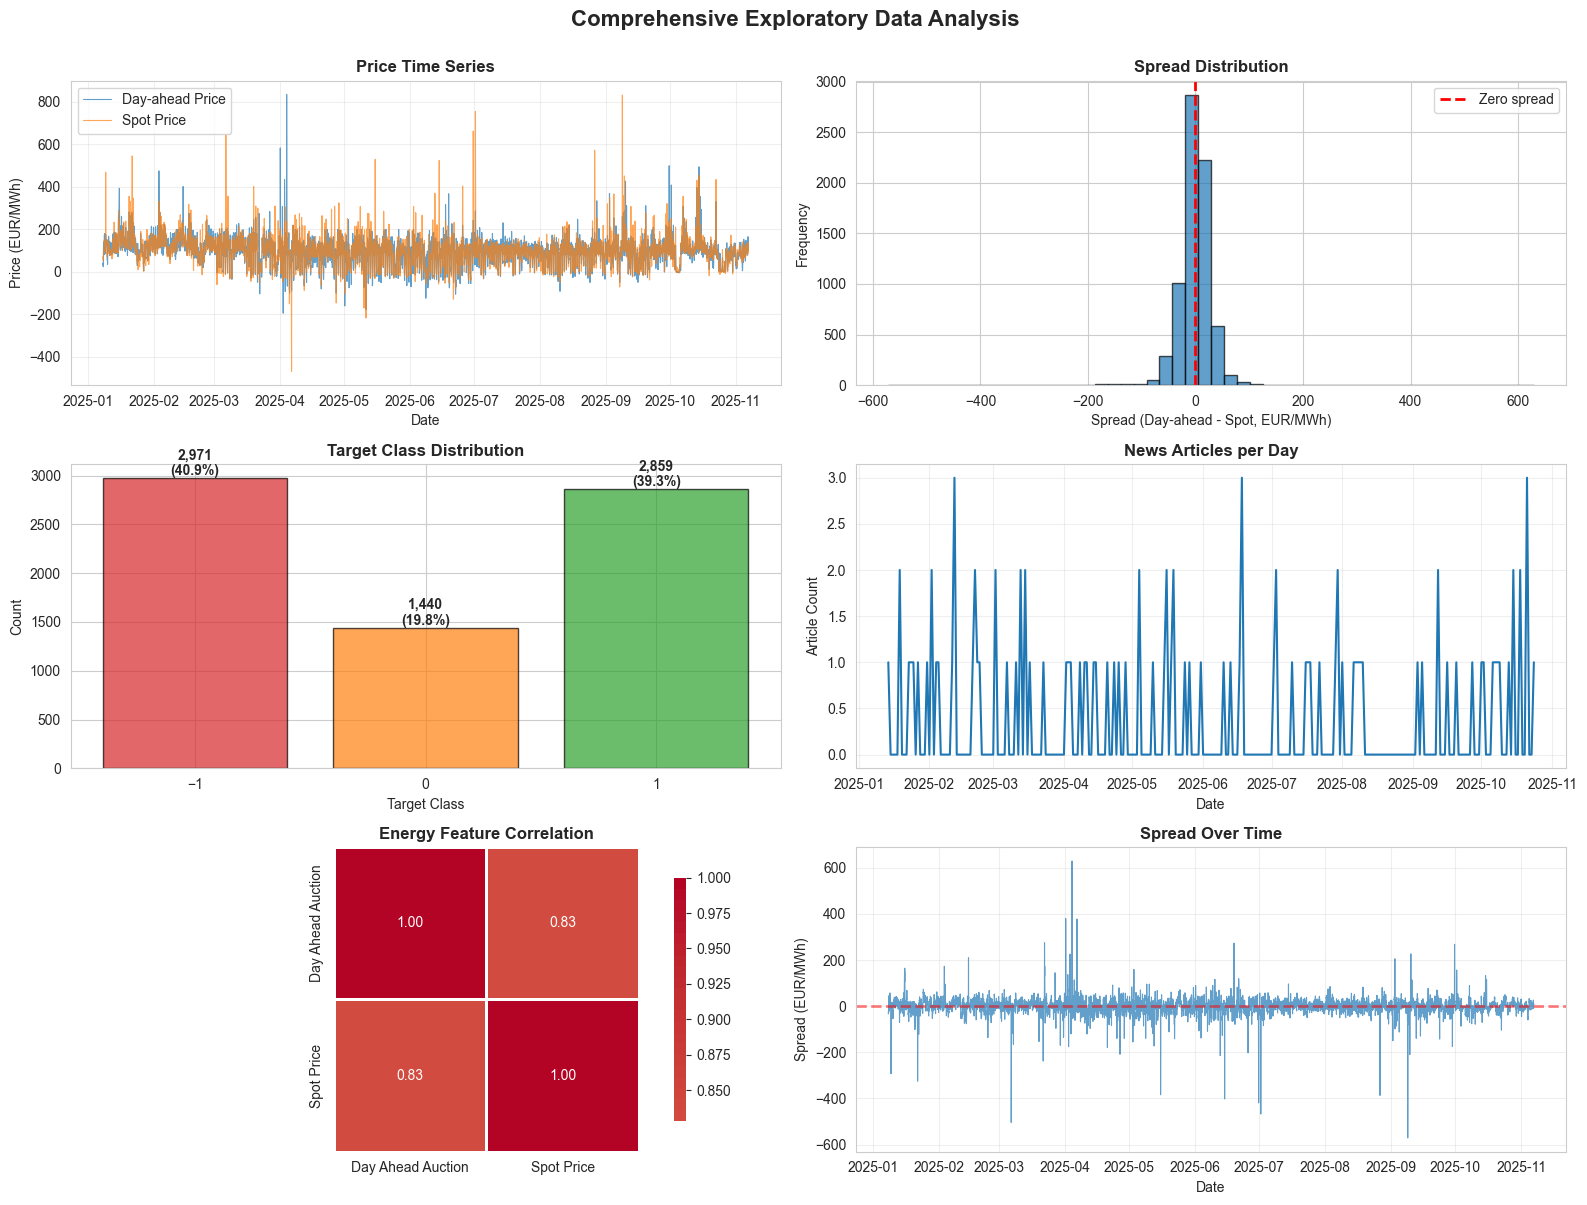


DATA SUMMARY
Date range: 2025-01-08 00:00:00 to 2025-11-06 21:00:00
Total hours: 7,270
Total news articles: 100

Target distribution:
  Class -1:  2,971 ( 40.9%)
  Class  0:  1,440 ( 19.8%)
  Class  1:  2,859 ( 39.3%)

Price statistics (EUR/MWh):
  Day-ahead: mean=90.00, std=60.52
  Spot:      mean=90.88, std=62.50
  Spread:    mean=-0.88, std=36.13



In [38]:
# ============================================================================
# EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Helper function to get correct energy price columns
def get_column_name(possible_names, df):
    """Return the first matching name in possible_names that exists in df.columns."""
    for name in possible_names:
        if name in df.columns:
            return name
    return None

# Try to find correct columns for the auction and spot prices, robust to variant casing/format
day_ahead_col = get_column_name(['day_ahead_price', 'Day Ahead Auction', 'day ahead price', 'Day-ahead Price', 'day_ahead_auction'], master_df)
spot_price_col = get_column_name(['spot_price', 'Spot Price', 'spot price'], master_df)

if day_ahead_col is None or spot_price_col is None:
    raise KeyError(f"Could not find both required price columns in master_df. Found: {day_ahead_col} and {spot_price_col}")

# Determine time axis safely (column vs index)
if 'timestamp' in master_df.columns:
    time_axis = pd.to_datetime(master_df['timestamp'])
elif 'Timestamp' in master_df.columns:
    time_axis = pd.to_datetime(master_df['Timestamp'])
elif isinstance(master_df.index, pd.DatetimeIndex):
    time_axis = master_df.index
else:
    raise KeyError("No timestamp column or datetime index found in master_df.")

# Create comprehensive EDA dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Comprehensive Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Time series of prices
axes[0, 0].plot(time_axis, master_df[day_ahead_col],
                label='Day-ahead Price', alpha=0.7, linewidth=0.8)
axes[0, 0].plot(time_axis, master_df[spot_price_col],
                label='Spot Price', alpha=0.7, linewidth=0.8)
axes[0, 0].set_title('Price Time Series', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (EUR/MWh)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Spread distribution
spread_series = master_df[day_ahead_col] - master_df[spot_price_col]
spread_data = spread_series.dropna()
axes[0, 1].hist(spread_data, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Spread Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Spread (Day-ahead - Spot, EUR/MWh)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero spread')
axes[0, 1].legend()

# 3. Target class balance
target_col = get_column_name(
    ['spread_target_shift_24', 'spread_target', 'target'], master_df)
if target_col is not None:
    target_counts = master_df[target_col].value_counts().sort_index()
    color_palette = ['#d62728', '#ff7f0e', '#2ca02c']
    if len(target_counts) > 3:
        color_palette = color_palette + ['#9467bd', '#8c564b']
    axes[1, 0].bar(target_counts.index, target_counts.values,
                   edgecolor='black', alpha=0.7, color=color_palette[:len(target_counts)])
    axes[1, 0].set_title('Target Class Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Target Class')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks(target_counts.index)
    for i, v in enumerate(target_counts.values):
        axes[1, 0].text(target_counts.index[i], v, f'{v:,}\n({v/len(master_df)*100:.1f}%)',
                        ha='center', va='bottom', fontweight='bold')
else:
    axes[1, 0].text(0.5, 0.5, 'Target column not found',
                    ha='center', va='center', fontsize=12)
    axes[1, 0].set_title('Target Class Distribution', fontsize=12, fontweight='bold')

# 4. Articles per day (if news_df exists)
if 'news_df' in dir() and news_df is not None and len(news_df) > 0:
    # Assuming news_df has a datetime index or timestamp column
    if hasattr(news_df, 'index') and isinstance(news_df.index, pd.DatetimeIndex):
        articles_per_day = news_df.resample('D').size()
    else:
        # Try to find timestamp column
        time_col = [c for c in news_df.columns if 'time' in c.lower() or 'date' in c.lower()]
        if time_col:
            articles_per_day = news_df.set_index(pd.to_datetime(news_df[time_col[0]])).resample('D').size()
        else:
            articles_per_day = pd.Series([len(news_df)], index=[pd.Timestamp.now()])

    axes[1, 1].plot(articles_per_day.index, articles_per_day.values, linewidth=1.5)
    axes[1, 1].set_title('News Articles per Day', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Article Count')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'News data not available',
                    ha='center', va='center', fontsize=12)
    axes[1, 1].set_title('News Articles per Day', fontsize=12, fontweight='bold')

# 5. Correlation heatmap of energy features
energy_features = []
for price_col in [day_ahead_col, spot_price_col]:
    if price_col is not None:
        energy_features.append(price_col)
# Add renewable energy columns if they exist
for col in ['solar', 'wind_onshore', 'wind_offshore', 'biomass', 'hydro']:
    if col in master_df.columns:
        energy_features.append(col)

if len(energy_features) >= 2:
    corr_matrix = master_df[energy_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=axes[2, 0], square=True, linewidths=1, cbar_kws={'shrink': 0.8})
    axes[2, 0].set_title('Energy Feature Correlation', fontsize=12, fontweight='bold')
else:
    axes[2, 0].text(0.5, 0.5, 'Insufficient features for correlation',
                    ha='center', va='center', fontsize=12)
    axes[2, 0].set_title('Energy Feature Correlation', fontsize=12, fontweight='bold')

# 6. Spread over time
axes[2, 1].plot(time_axis, spread_series, linewidth=0.8, alpha=0.7)
axes[2, 1].set_title('Spread Over Time', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Date')
axes[2, 1].set_ylabel('Spread (EUR/MWh)')
axes[2, 1].axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print data summary
print(f"\n{'='*60}")
print("DATA SUMMARY")
print(f"{'='*60}")
print(f"Date range: {time_axis.min()} to {time_axis.max()}")
print(f"Total hours: {len(master_df):,}")
if 'news_df' in dir() and news_df is not None:
    print(f"Total news articles: {len(news_df):,}")
if target_col is not None:
    print(f"\nTarget distribution:")
    for idx, count in master_df[target_col].value_counts().sort_index().items():
        # format idx safely: if it is int, print as int, else use general format
        if isinstance(idx, (int,)) or (isinstance(idx, float) and idx.is_integer()):
            idx_str = f"{int(idx):2d}"
        else:
            idx_str = f"{idx}"
        print(f"  Class {idx_str}: {count:6,} ({count/len(master_df)*100:5.1f}%)")
else:
    print("\nTarget column not found for distribution statistics.")
print(f"\nPrice statistics (EUR/MWh):")
print(f"  Day-ahead: mean={master_df[day_ahead_col].mean():.2f}, "
      f"std={master_df[day_ahead_col].std():.2f}")
print(f"  Spot:      mean={master_df[spot_price_col].mean():.2f}, "
      f"std={master_df[spot_price_col].std():.2f}")
print(f"  Spread:    mean={spread_data.mean():.2f}, std={spread_data.std():.2f}")
print(f"{'='*60}\n")

In [39]:
with StageProfiler("Stage 3 — Dataset scaling", device_config):
    # Pre-scale all 20 preprocessed datasets
    # Fit scaler on training set and transform train/validation/test sets
    print("Pre-scaling all 20 datasets...")
    print("Fitting scaler on training set and transforming all splits\n")

    for params_key, data_dict in preprocessed_datasets.items():
        train_df = data_dict['train_df']
        val_df = data_dict['val_df']
        test_df = data_dict['test_df']
        news_features = data_dict['news_features']

        # Fit scaler on training set's news features only
        scaler_news = StandardScaler()
        train_news_features = train_df[news_features].fillna(0)
        scaler_news.fit(train_news_features)

        # Transform all splits using the fitted scaler
        # We'll create new columns with '_scaled' suffix for the news features
        for df_name, df in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
            news_data = df[news_features].fillna(0)
            news_scaled = scaler_news.transform(news_data)

            # Create scaled column names
            for idx, feat in enumerate(news_features):
                scaled_col = f"{feat}_scaled"
                df[scaled_col] = news_scaled[:, idx]

            # Update the dataframe in the dictionary
            data_dict[df_name] = df

        # Store the scaler for later use
        data_dict['scaler_news'] = scaler_news

        # Store scaled news feature names
        scaled_news_features = [f"{feat}_scaled" for feat in news_features]
        data_dict['scaled_news_features'] = scaled_news_features

    print("Scaling complete! All datasets have been scaled.")
    # Get sample scaled feature count from first dataset
    sample_key = list(preprocessed_datasets.keys())[0]
    sample_scaled_features = preprocessed_datasets[sample_key]['scaled_news_features']
    print(f"Scaled news features created: {len(sample_scaled_features)} features per dataset")



[Stage ⏳] Stage 3 — Dataset scaling — starting
Pre-scaling all 20 datasets...
Fitting scaler on training set and transforming all splits

Scaling complete! All datasets have been scaled.
Scaled news features created: 28 features per dataset
[Stage ✅] Stage 3 — Dataset scaling — completed in 0.05s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +0.0 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


In [40]:
TARGET_COLUMN = 'spread_target_shift_24'
DEFAULT_ALPHAS = np.logspace(-3, 3, 13)


def evaluate_single_parameter_combination(params_key, data_dict, baseline_features,
                                          alphas=None, max_splits=5):
    """Evaluate a single parameter combination using expanding-window RidgeCV confined to the training split."""
    lw, dl = params_key
    dataset_name = data_dict['dataset_name']
    train_df = data_dict['train_df']
    val_df = data_dict['val_df']
    scaled_news_features = data_dict['scaled_news_features']

    feature_columns = baseline_features + scaled_news_features
    missing_features = [col for col in feature_columns if col not in train_df.columns]
    if missing_features:
        raise ValueError(f"Missing features {missing_features} in dataset {dataset_name}")

    if alphas is None:
        alphas = DEFAULT_ALPHAS

    X_train = train_df[feature_columns].fillna(0)
    y_train = train_df[TARGET_COLUMN].astype(int)
    X_val = val_df[feature_columns].fillna(0)
    y_val = val_df[TARGET_COLUMN].astype(int)

    unique_classes = np.unique(y_train)
    if unique_classes.size < 2:
        return {
            'lookback_window': lw,
            'decay_lambda': dl,
            'dataset_name': dataset_name,
            'best_alpha': None,
            'val_accuracy': np.nan,
            'val_macro_f1': np.nan,
            'model': None,
            'params_key': params_key,
            'skip_reason': 'Training split lacks class diversity'
        }

    if len(X_val) == 0:
        return {
            'lookback_window': lw,
            'decay_lambda': dl,
            'dataset_name': dataset_name,
            'best_alpha': None,
            'val_accuracy': np.nan,
            'val_macro_f1': np.nan,
            'model': None,
            'params_key': params_key,
            'skip_reason': 'Validation split is empty'
        }

    max_possible_splits = max(0, len(X_train) - 1)
    effective_splits = min(max_splits, max_possible_splits)

    if effective_splits < 2:
        return {
            'lookback_window': lw,
            'decay_lambda': dl,
            'dataset_name': dataset_name,
            'best_alpha': None,
            'val_accuracy': np.nan,
            'val_macro_f1': np.nan,
            'model': None,
            'params_key': params_key,
            'skip_reason': 'Insufficient data for expanding-window CV'
        }

    tscv = TimeSeriesSplit(n_splits=effective_splits)

    ridge_cv = RidgeClassifierCV(alphas=alphas, cv=tscv, scoring='accuracy')
    ridge_cv.fit(X_train, y_train)

    val_predictions = ridge_cv.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_predictions)
    val_macro_f1 = f1_score(y_val, val_predictions, average='macro', zero_division=0)

    return {
        'lookback_window': lw,
        'decay_lambda': dl,
        'dataset_name': dataset_name,
        'best_alpha': ridge_cv.alpha_,
        'val_accuracy': val_accuracy,
        'val_macro_f1': val_macro_f1,
        'model': ridge_cv,
        'params_key': params_key,
        'skip_reason': None
    }


def grid_search_time_decay_params(preprocessed_datasets, baseline_features,
                                  alphas=None, max_splits=5):
    """Run expanding-window RidgeCV on each precomputed dataset and rank by validation performance."""
    print(f"Grid searching {len(preprocessed_datasets)} parameter combinations...")
    print(f"Using expanding-window RidgeCV confined to training splits (target: {TARGET_COLUMN})")
    print(f"Parallelizing evaluation across parameter combinations using joblib...\n")

    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_single_parameter_combination)(
            params_key,
            data_dict,
            baseline_features,
            alphas,
            max_splits
        )
        for params_key, data_dict in preprocessed_datasets.items()
    )

    # Filter out combinations that could not be evaluated
    valid_results = [res for res in results if res['skip_reason'] is None]
    invalid_results = [res for res in results if res['skip_reason'] is not None]

    if invalid_results:
        print("The following combinations were skipped:")
        for res in invalid_results:
            print(f"  - {res['dataset_name']} (lookback={res['lookback_window']}, lambda={res['decay_lambda']}): {res['skip_reason']}")
        print()

    if not valid_results:
        print("No valid results to rank. Please review the dataset or parameters.")
        return []

    # Sort by validation accuracy (descending), then macro F1
    results_sorted = sorted(
        valid_results,
        key=lambda x: (x['val_accuracy'], x['val_macro_f1']),
        reverse=True
    )

    globals()['ridgecv_valid_results'] = valid_results
    globals()['ridgecv_results_sorted'] = results_sorted

    top_results = results_sorted[:3]

    print(f"{'='*80}")
    print("TOP 3 PARAMETER COMBINATIONS:")
    print(f"{'='*80}")
    for idx, result in enumerate(top_results, 1):
        print(
            f"{idx}. dataset={result['dataset_name']} | lookback={result['lookback_window']}h | "
            f"lambda={result['decay_lambda']} | alpha={result['best_alpha']:.4f} | "
            f"Val Accuracy={result['val_accuracy']:.3f} | Val Macro-F1={result['val_macro_f1']:.3f}"
        )

    return top_results


In [41]:
# Define baseline features (will be used for all combinations)
# Note: Data splitting is now done in the preprocessing step (Cells 33-34)
baseline_features = [
    'price_lag_24', 'price_lag_168',
    'load_lag_24', 'load_lag_168',
    'hour', 'month', 'day_of_week', 'day_of_year', 'week_of_year'
]

print("Baseline features defined:")
print(baseline_features)


Baseline features defined:
['price_lag_24', 'price_lag_168', 'load_lag_24', 'load_lag_168', 'hour', 'month', 'day_of_week', 'day_of_year', 'week_of_year']


In [42]:
with StageProfiler("Stage 3 — Ridge feature selection", device_config):
    # Run grid search to find top 3 parameter combinations using expanding-window RidgeCV
    top_3_combinations = grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        alphas=DEFAULT_ALPHAS,
        max_splits=5
    )



[Stage ⏳] Stage 3 — Ridge feature selection — starting
Grid searching 6 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   6 | elapsed:    0.2s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    0.2s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   4 out of   6 | elapsed:    0.2s remaining:    0.1s


TOP 3 PARAMETER COMBINATIONS:
1. dataset=master_df_pre_3 | lookback=168h | lambda=0.05 | alpha=1000.0000 | Val Accuracy=0.417 | Val Macro-F1=0.312
2. dataset=master_df_pre_2 | lookback=168h | lambda=0.02 | alpha=1000.0000 | Val Accuracy=0.411 | Val Macro-F1=0.293
3. dataset=master_df_pre_4 | lookback=336h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.411 | Val Macro-F1=0.274
[Stage ✅] Stage 3 — Ridge feature selection — completed in 1.47s
  CPU usage: 43.6% • IO wait: 0.00%
  Disk Δ: +10.0 MB read, +1.2 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    1.5s finished


In [43]:
# Create a compact summary DataFrame for downstream reporting of the top combinations
if 'top_3_combinations' in globals() and top_3_combinations:
    top_3_summary = pd.DataFrame([
        {
            'dataset_name': res['dataset_name'],
            'lookback_window': res['lookback_window'],
            'decay_lambda': res['decay_lambda'],
            'best_alpha': res['best_alpha'],
            'val_accuracy': res['val_accuracy'],
            'val_macro_f1': res['val_macro_f1']
        }
        for res in top_3_combinations
    ])
    display(top_3_summary)
else:
    print("No top combinations available to summarize.")



,dataset_name,lookback_window,decay_lambda,best_alpha,val_accuracy,val_macro_f1
0,master_df_pre_3,168,0.05,1000.0,0.416781,0.311749
1,master_df_pre_2,168,0.02,1000.0,0.410591,0.293145
2,master_df_pre_4,336,0.01,1000.0,0.410591,0.274215


In [44]:
# Inspect feature availability for the top 3 datasets
if 'top_3_combinations' not in globals() or not top_3_combinations:
    raise RuntimeError("top_3_combinations is not defined. Please rerun the RidgeCV selection cells.")

for rank, result in enumerate(top_3_combinations, start=1):
    params_key = result['params_key']
    dataset_name = result['dataset_name']
    data_dict = preprocessed_datasets[params_key]
    train_df = data_dict['train_df']
    val_df = data_dict['val_df']
    test_df = data_dict['test_df']
    scaled_news_features = data_dict['scaled_news_features']

    print(f"#{rank} {dataset_name} -> lookback: {result['lookback_window']}h, decay_lambda: {result['decay_lambda']}")
    print(f"  Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")
    print(f"  Baseline features present: {all(feat in train_df.columns for feat in baseline_features)}")
    print(f"  Scaled news features count: {len(scaled_news_features)}")
    print(f"  Class distribution (train):\n{train_df[TARGET_COLUMN].value_counts(dropna=False)}\n")


#1 master_df_pre_3 -> lookback: 168h, decay_lambda: 0.05
  Train size: 5089, Validation size: 1454, Test size: 727
  Baseline features present: True
  Scaled news features count: 28
  Class distribution (train):
spread_target_shift_24
-1.0    2163
 1.0    2032
 0.0     894
Name: count, dtype: int64

#2 master_df_pre_2 -> lookback: 168h, decay_lambda: 0.02
  Train size: 5089, Validation size: 1454, Test size: 727
  Baseline features present: True
  Scaled news features count: 28
  Class distribution (train):
spread_target_shift_24
-1.0    2163
 1.0    2032
 0.0     894
Name: count, dtype: int64

#3 master_df_pre_4 -> lookback: 336h, decay_lambda: 0.01
  Train size: 5089, Validation size: 1454, Test size: 727
  Baseline features present: True
  Scaled news features count: 28
  Class distribution (train):
spread_target_shift_24
-1.0    2163
 1.0    2032
 0.0     894
Name: count, dtype: int64



In [45]:
def run_xgb_random_search(
    data_dict: dict,
    baseline_features: list,
    param_distributions: dict | None = None,
    n_iter: int = 40,
    random_state: int = 42,
    n_splits: int = DEFAULT_EXPANDING_SPLITS,
    step_size: int = DEFAULT_EXPANDING_STEP,
    min_train_size: int = DEFAULT_MIN_TRAIN_SIZE,
    device_config: dict | None = None
):
    """GPU-aware XGBoost random search wrapper (overrides legacy definition)."""
    if param_distributions is None:
        param_distributions = XGB_PARAM_DISTRIBUTIONS

    train_df = data_dict['train_df']
    scaled_news_features = data_dict['scaled_news_features']
    feature_columns = baseline_features + scaled_news_features
    missing_features = [col for col in feature_columns if col not in train_df.columns]
    if missing_features:
        raise KeyError(f"Missing features in training dataframe: {missing_features}")

    X_train = train_df[feature_columns].fillna(0)
    y_train_raw = train_df[TARGET_COLUMN].astype(int)
    y_train = map_target_to_binary(y_train_raw)

    splitter = ExpandingWindowSplitter(
        n_splits=n_splits,
        step_size=step_size,
        min_train_size=min_train_size
    )

    effective_splits = splitter.get_n_splits(X_train)
    if effective_splits < n_splits:
        raise ValueError(
            f"Only {effective_splits} expanding-window splits available. Adjust n_splits, step_size, "
            f"or min_train_size."
        )

    classifier = build_xgb_classifier(random_state=random_state, device_config=device_config)

    if device_config is None:
        search_n_jobs = -1
    elif device_config.get('device') == 'cuda':
        search_n_jobs = 1
    else:
        search_n_jobs = device_config.get('n_jobs', -1)

    if device_config and device_config.get('device') == 'cuda':
        print("Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).")
    elif device_config and device_config.get('device') == 'mps':
        print("MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.")
    else:
        print(f"Using CPU-optimised XGBoost with parallel CV fits (n_jobs={search_n_jobs}).")

    search = RandomizedSearchCV(
        estimator=classifier,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring='f1_macro',
        cv=splitter,
        n_jobs=search_n_jobs,
        random_state=random_state,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)
    return search, feature_columns


In [46]:
ensure_disk_headroom(Path('.'), min_free_gb=5.0)


In [49]:
class ExpandingWindowSplitter:
    """Custom expanding-window splitter with fixed step size for time series CV."""

    def __init__(self, n_splits=N_CV_SPLITS, step_size=CV_STEP_SIZE_HOURS, min_train_size=CV_MIN_TRAIN_SIZE):
        if n_splits < 1:
            raise ValueError("n_splits must be at least 1")
        if step_size < 1:
            raise ValueError("step_size must be at least 1")
        if min_train_size < 1:
            raise ValueError("min_train_size must be at least 1")

        self.n_splits = n_splits
        self.step_size = step_size
        self.min_train_size = min_train_size

    def get_n_splits(self, X=None, y=None, groups=None):
        if X is None:
            return self.n_splits
        n_samples = len(X)
        if n_samples <= self.min_train_size:
            return 0
        possible_splits = (n_samples - self.min_train_size) // self.step_size
        return max(0, min(self.n_splits, possible_splits))

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        effective_splits = self.get_n_splits(X)
        if effective_splits < self.n_splits:
            raise ValueError(
                f"Requested {self.n_splits} splits, but only {effective_splits} are possible with "
                f"{n_samples} samples. Consider reducing n_splits or the step_size/min_train_size."
            )

        train_end = self.min_train_size
        for split_idx in range(self.n_splits):
            test_start = train_end
            test_end = test_start + self.step_size
            if test_end > n_samples:
                raise ValueError(
                    f"Split {split_idx} exceeds available samples ({n_samples}). "
                    "Try reducing n_splits or step_size."
                )

            train_indices = np.arange(0, train_end)
            test_indices = np.arange(test_start, test_end)
            yield train_indices, test_indices

            train_end = test_end


In [50]:
# Ensure defaults remain defined even if earlier cell is skipped
DEFAULT_EXPANDING_SPLITS = globals().get("DEFAULT_EXPANDING_SPLITS", 4)
DEFAULT_EXPANDING_STEP = globals().get("DEFAULT_EXPANDING_STEP", 12)
DEFAULT_MIN_TRAIN_SIZE = globals().get("DEFAULT_MIN_TRAIN_SIZE", 336)  # 2 weeks of hourly observations

XGB_PARAM_DISTRIBUTIONS = {
    'n_estimators': stats.randint(200, 800),
    'max_depth': stats.randint(2, 9),
    'learning_rate': stats.loguniform(0.01, 0.3),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'gamma': stats.uniform(0.0, 5.0),
    'min_child_weight': stats.randint(1, 10),
    'reg_alpha': stats.loguniform(1e-4, 1e1),
    'reg_lambda': stats.loguniform(1e-3, 1e2)
}


def build_xgb_classifier(random_state: int = 42, device_config: dict | None = None) -> XGBClassifier:
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'enable_categorical': False,
        'random_state': random_state
    }

    if device_config is None:
        params.update({'tree_method': 'hist', 'predictor': 'auto', 'n_jobs': -1})
    else:
        params.update({
            'tree_method': device_config.get('tree_method', 'hist'),
            'predictor': device_config.get('predictor', 'auto'),
            'n_jobs': device_config.get('n_jobs', -1)
        })

    return XGBClassifier(**params)


def map_target_to_binary(y: pd.Series) -> np.ndarray:
    unique_values = set(np.unique(y))
    unexpected_values = unique_values - {-1, 0, 1}
    if unexpected_values:
        raise ValueError(f"Unexpected target values encountered: {unexpected_values}")
    return np.where(y > 0, 1, 0)


def run_xgb_random_search(
    data_dict: dict,
    baseline_features: list,
    param_distributions: dict | None = None,
    n_iter: int = 40,
    random_state: int = 42,
    n_splits: int = DEFAULT_EXPANDING_SPLITS,
    step_size: int = DEFAULT_EXPANDING_STEP,
    min_train_size: int = DEFAULT_MIN_TRAIN_SIZE,
    device_config: dict | None = None
):
    if param_distributions is None:
        param_distributions = XGB_PARAM_DISTRIBUTIONS

    train_df = data_dict['train_df']
    scaled_news_features = data_dict['scaled_news_features']
    feature_columns = baseline_features + scaled_news_features
    missing_features = [col for col in feature_columns if col not in train_df.columns]
    if missing_features:
        raise KeyError(f"Missing features in training dataframe: {missing_features}")

    X_train = train_df[feature_columns].fillna(0)
    y_train_raw = train_df[TARGET_COLUMN].astype(int)
    y_train = map_target_to_binary(y_train_raw)

    unique_classes = np.unique(y_train)
    if unique_classes.size < 2:
        raise ValueError("Training data must contain at least two classes for classification.")

    splitter = ExpandingWindowSplitter(
        n_splits=n_splits,
        step_size=step_size,
        min_train_size=min_train_size
    )

    effective_splits = splitter.get_n_splits(X_train)
    if effective_splits < n_splits:
        raise ValueError(
            f"Only {effective_splits} expanding-window splits available. Adjust n_splits, step_size, "
            f"or min_train_size."
        )

    classifier = build_xgb_classifier(random_state=random_state, device_config=device_config)

    if device_config is None:
        search_n_jobs = -1
    elif device_config.get('device') == 'cuda':
        search_n_jobs = 1  # avoid oversubscribing a single GPU across parallel CV folds
    else:
        search_n_jobs = -1

    if device_config and device_config.get('device') == 'cuda':
        print("Running RandomizedSearchCV with CUDA-accelerated XGBoost (serial CV fits).")
    elif device_config and device_config.get('device') == 'mps':
        print("MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.")
    else:
        print("Using CPU-optimised XGBoost with parallel CV fits.")

    search = RandomizedSearchCV(
        estimator=classifier,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring='f1_macro',
        cv=splitter,
        n_jobs=search_n_jobs,
        random_state=random_state,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)
    return search, feature_columns


In [51]:
with StageProfiler("Stage 3 — Modeling & Hyperparameter Search", device_config):
    xgb_tuning_runs = []
    xgb_best_models = {}
    xgb_validation_predictions = {}

    if 'top_3_combinations' not in globals() or not top_3_combinations:
        raise RuntimeError("top_3_combinations is not defined. Run the RidgeCV selection first.")

    xgb_device_config = detect_compute_device(task='training', verbose=True)
    print(
        f"XGBoost device: {xgb_device_config.get('description')} • tree_method={xgb_device_config.get('tree_method')} • jobs={xgb_device_config.get('n_jobs')}"
    )

    for rank, result in enumerate(top_3_combinations, start=1):
        params_key = result['params_key']
        dataset_name = result['dataset_name']
        data_dict = preprocessed_datasets[params_key]

        print("=" * 100)
        print(f"Tuning XGBoost for #{rank}: {dataset_name}")
        search, feature_columns = run_xgb_random_search(
            data_dict=data_dict,
            baseline_features=baseline_features,
            n_iter=40,
            random_state=RANDOM_STATE,
            device_config=xgb_device_config
        )

        best_estimator = search.best_estimator_
        # evaluate on validation split (binary target)
        val_df = data_dict['val_df']
        X_val = val_df[feature_columns].fillna(0)
        y_val_binary = map_target_to_binary(val_df[TARGET_COLUMN].astype(int))

        val_proba = best_estimator.predict_proba(X_val)[:, 1]
        val_pred_binary = (val_proba >= 0.5).astype(int)

        run_summary = {
            'rank': rank,
            'dataset_name': dataset_name,
            'params_key': params_key,
            'lookback_window': result['lookback_window'],
            'decay_lambda': result['decay_lambda'],
            'best_params': search.best_params_,
            'best_cv_macro_f1': search.best_score_,
            'val_macro_f1': f1_score(y_val_binary, val_pred_binary, average='macro', zero_division=0),
            'val_accuracy': accuracy_score(y_val_binary, val_pred_binary),
            'feature_columns': feature_columns,
            'search_object': search,
            'device_config': xgb_device_config,
        }

        xgb_tuning_runs.append(run_summary)
        xgb_best_models[dataset_name] = best_estimator


[Stage ⏳] Stage 3 — Modeling & Hyperparameter Search — starting
✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)
XGBoost device: Apple MPS GPU • tree_method=hist • jobs=6
Tuning XGBoost for #1: master_df_pre_3
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits
Tuning XGBoost for #2: master_df_pre_2
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits
Tuning XGBoost for #3: master_df_pre_4
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 4 folds for each of 40 candidates, totalling 160 fits
[Stage ✅] Stage 3 — Modeling & Hyperparameter Search — completed in 18.66s
  CPU usage: 79.5% • IO wait: 0.00%
  Disk Δ: +204.5 MB read, +533.8 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


In [52]:
ensure_disk_headroom(Path('.'), min_free_gb=5.0)


In [53]:
# Summarise tuning outcomes and select the best-performing dataset/model
if not xgb_tuning_runs:
    raise RuntimeError("No XGBoost tuning runs were completed. Check previous cells for errors.")

xgb_results_df = pd.DataFrame([
    {
        'rank': run['rank'],
        'dataset_name': run['dataset_name'],
        'lookback_window': run['lookback_window'],
        'decay_lambda': run['decay_lambda'],
        'device': run['device_config'].get('description', 'N/A'),
        'best_cv_macro_f1': run['best_cv_macro_f1'],
        'val_macro_f1': run['val_macro_f1'],
        'val_accuracy': run['val_accuracy'],
        'best_params': run['best_params']
    }
    for run in xgb_tuning_runs
]).sort_values(by='val_macro_f1', ascending=False).reset_index(drop=True)

display(xgb_results_df)

best_run = xgb_results_df.iloc[0]
best_dataset_name = best_run['dataset_name']
best_model = xgb_best_models[best_dataset_name]
best_run_details = next(run for run in xgb_tuning_runs if run['dataset_name'] == best_dataset_name)

xgb_model_registry = {
    run['dataset_name']: {
        'best_estimator': xgb_best_models[run['dataset_name']],
        'feature_columns': run['feature_columns'],
        'params_key': run['params_key'],
        'lookback_window': run['lookback_window'],
        'decay_lambda': run['decay_lambda'],
        'best_params': run['best_params'],
        'best_cv_macro_f1': run['best_cv_macro_f1'],
        'val_macro_f1': run['val_macro_f1'],
        'val_accuracy': run['val_accuracy'],
        'search_object': run['search_object'],
        'device_config': run['device_config']
    }
    for run in xgb_tuning_runs
}

best_xgb_model_selection = {
    'dataset_name': best_dataset_name,
    'params_key': best_run_details['params_key'],
    'lookback_window': best_run_details['lookback_window'],
    'decay_lambda': best_run_details['decay_lambda'],
    'best_params': best_run_details['best_params'],
    'best_estimator': best_model,
    'feature_columns': best_run_details['feature_columns'],
    'validation_metrics': {
        'macro_f1': best_run_details['val_macro_f1'],
        'accuracy': best_run_details['val_accuracy']
    },
    'cv_macro_f1': best_run_details['best_cv_macro_f1'],
    'device_config': best_run_details['device_config']
}

print("Selected model for downstream forecasting:")
print(best_xgb_model_selection)

,rank,dataset_name,lookback_window,decay_lambda,device,best_cv_macro_f1,val_macro_f1,val_accuracy,best_params
0,1,master_df_pre_3,168,0.05,Apple MPS GPU,0.747222,0.579195,0.602476,"{'colsample_bytree': 0.6682096494749166, 'gamm..."
1,3,master_df_pre_4,336,0.01,Apple MPS GPU,0.703819,0.558200,0.646492,"{'colsample_bytree': 0.610167650697638, 'gamma..."
2,2,master_df_pre_2,168,0.02,Apple MPS GPU,0.727485,0.537135,0.568088,"{'colsample_bytree': 0.6682096494749166, 'gamm..."


Selected model for downstream forecasting:
{'dataset_name': 'master_df_pre_3', 'params_key': (168, 0.05), 'lookback_window': 168, 'decay_lambda': 0.05, 'best_params': {'colsample_bytree': np.float64(0.6682096494749166), 'gamma': np.float64(0.3252579649263976), 'learning_rate': np.float64(0.2521267904777921), 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 545, 'reg_alpha': np.float64(0.0003078651783619622), 'reg_lambda': np.float64(2.6373339933815254), 'subsample': np.float64(0.7760609974958406)}, 'best_estimator': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6682096494749166), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=np.float64(0.3252579649263976), grow_policy=None,
              importance_type=None, interaction_constrain

In [54]:
if 'telemetry_logger' in globals():
    if 'best_xgb_model_selection' in globals() and best_xgb_model_selection is not None:
        telemetry_logger.metadata.update({
            'selected_dataset': best_xgb_model_selection['dataset_name'],
            'selected_params': str(best_xgb_model_selection['best_params']),
        })
    else:
        telemetry_logger.metadata.update({
            'selected_dataset': None,
            'selected_params': None,
        })
        print("Telemetry logger active, but 'best_xgb_model_selection' is not defined yet.")


## LightGBM Signal Decision Model

We now build a second-stage model that maps XGBoost forecasts and price inputs to long/short/hold trading signals.


In [55]:
# Prepare features for the LightGBM signal model using best XGBoost forecasts
if 'best_xgb_model_selection' not in globals():
    raise RuntimeError("best_xgb_model_selection is not defined. Please run the XGBoost tuning cells first.")

signal_params_key = best_xgb_model_selection['params_key']
signal_dataset_name = best_xgb_model_selection['dataset_name']

if signal_params_key not in preprocessed_datasets:
    raise KeyError(f"Dataset for params {signal_params_key} not found in preprocessed_datasets.")

signal_data_dict = preprocessed_datasets[signal_params_key]
train_df = signal_data_dict['train_df'].copy()
val_df = signal_data_dict['val_df'].copy()
test_df = signal_data_dict['test_df'].copy()

xgb_feature_columns = best_xgb_model_selection['feature_columns']
xgb_best_estimator = best_xgb_model_selection['best_estimator']
xgb_device_config = best_xgb_model_selection.get('device_config', {'device': 'cpu', 'tree_method': 'hist', 'predictor': 'auto', 'n_jobs': -1})

# Resolve price columns (handle different naming conventions)
def resolve_column(df: pd.DataFrame, candidates: list[str], logical_name: str) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"None of the candidate columns {candidates} found for '{logical_name}'. Available columns: {list(df.columns)[:20]} ...")

DAY_AHEAD_COL = resolve_column(train_df, ['Day Ahead Auction', 'day_ahead_auction', 'day_ahead_price'], 'day_ahead_price')
SPOT_COL = resolve_column(train_df, ['Spot Price', 'spot_price'], 'spot_price')

# Helper to instantiate fresh XGBoost classifiers with the best parameters
base_xgb_params = xgb_best_estimator.get_params()
base_xgb_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'enable_categorical': False,
    'tree_method': xgb_device_config.get('tree_method', 'hist'),
    'predictor': xgb_device_config.get('predictor', 'auto'),
    'n_jobs': xgb_device_config.get('n_jobs', -1)
})

def create_xgb_clone() -> XGBClassifier:
    sanitized_params = {}
    for key, value in base_xgb_params.items():
        if isinstance(value, (np.floating, np.float32, np.float64)):
            sanitized_params[key] = float(value)
        elif isinstance(value, (np.integer, np.int32, np.int64)):
            sanitized_params[key] = int(value)
        else:
            sanitized_params[key] = value
    model = XGBClassifier(**sanitized_params)
    return model

# Compute out-of-fold probabilities on the training split (binary target for XGBoost)
X_train_full = train_df[xgb_feature_columns].fillna(0)
y_train_signed = train_df[TARGET_COLUMN].astype(int)
y_train_binary = map_target_to_binary(y_train_signed)

splitter = ExpandingWindowSplitter(
    n_splits=DEFAULT_EXPANDING_SPLITS,
    step_size=DEFAULT_EXPANDING_STEP,
    min_train_size=DEFAULT_MIN_TRAIN_SIZE
)

expected_splits = splitter.get_n_splits(X_train_full)
if expected_splits < DEFAULT_EXPANDING_SPLITS:
    raise ValueError(
        f"Not enough data for the configured expanding-window splits ({expected_splits} < {DEFAULT_EXPANDING_SPLITS})."
    )

oof_probas = np.full(len(X_train_full), np.nan, dtype=float)
oof_fold_ids = np.full(len(X_train_full), -1, dtype=int)

for fold_idx, (tr_idx, va_idx) in enumerate(splitter.split(X_train_full), start=1):
    xgb_model = create_xgb_clone()
    xgb_model.fit(X_train_full.iloc[tr_idx], y_train_binary[tr_idx])
    fold_proba = xgb_model.predict_proba(X_train_full.iloc[va_idx])[:, 1]
    oof_probas[va_idx] = fold_proba
    oof_fold_ids[va_idx] = fold_idx

# Fill any remaining gaps (e.g., tail samples) with predictions from the refit estimator
missing_mask = np.isnan(oof_probas)
if missing_mask.any():
    backup_proba = xgb_best_estimator.predict_proba(X_train_full.iloc[missing_mask])[:, 1]
    oof_probas[missing_mask] = backup_proba
    oof_fold_ids[missing_mask] = 0  # mark as filled from refit model

train_signal_features = pd.DataFrame({
    'xgb_proba': oof_probas,
    'xgb_confidence': np.abs(oof_probas - 0.5) * 2,
    'day_ahead_price': train_df[DAY_AHEAD_COL].values,
    'spot_price': train_df[SPOT_COL].values,
}, index=train_df.index)
train_signal_target = y_train_signed

# Prepare validation features using the refit estimator (trained on full training split)
X_val = val_df[xgb_feature_columns].fillna(0)
y_val_signed = val_df[TARGET_COLUMN].astype(int)
val_probas = xgb_best_estimator.predict_proba(X_val)[:, 1]
val_signal_features = pd.DataFrame({
    'xgb_proba': val_probas,
    'xgb_confidence': np.abs(val_probas - 0.5) * 2,
    'day_ahead_price': val_df[DAY_AHEAD_COL].values,
    'spot_price': val_df[SPOT_COL].values,
}, index=val_df.index)
val_signal_target = y_val_signed

# Fit a fresh XGBoost model on train+validation to generate test-set forecasts
X_full = pd.concat([X_train_full, X_val], axis=0)
y_full_binary = map_target_to_binary(pd.concat([train_signal_target, val_signal_target], axis=0))

xgb_full_model = create_xgb_clone()
xgb_full_model.fit(X_full, y_full_binary)

X_test = test_df[xgb_feature_columns].fillna(0)
y_test_signed = test_df[TARGET_COLUMN].astype(int)
test_probas = xgb_full_model.predict_proba(X_test)[:, 1]

test_signal_features = pd.DataFrame({
    'xgb_proba': test_probas,
    'xgb_confidence': np.abs(test_probas - 0.5) * 2,
    'day_ahead_price': test_df[DAY_AHEAD_COL].values,
    'spot_price': test_df[SPOT_COL].values,
}, index=test_df.index)
test_signal_target = y_test_signed

print(f"Prepared signal datasets for '{signal_dataset_name}' with features: {list(train_signal_features.columns)}")
print(f"Train samples: {len(train_signal_features)}, Validation samples: {len(val_signal_features)}, Test samples: {len(test_signal_features)}")


Prepared signal datasets for 'master_df_pre_3' with features: ['xgb_proba', 'xgb_confidence', 'day_ahead_price', 'spot_price']
Train samples: 5089, Validation samples: 1454, Test samples: 727


In [56]:
lgbm_device_config = detect_compute_device(task='training', verbose=True)
print(
    f"LightGBM device: {lgbm_device_config.get('description')} • backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • jobs={lgbm_device_config.get('n_jobs')}"
)

with StageProfiler("Stage 3 — LightGBM signal model", device_config):
    # Train LightGBM decision model with GridSearchCV on OOF-augmented features
    label_encoder = LabelEncoder()
    label_encoder.fit([-1, 0, 1])  # ensure consistent mapping across all splits

    y_train_encoded = label_encoder.transform(train_signal_target)

    def build_lgbm_classifier(random_state: int = 42) -> lgb.LGBMClassifier:
        params = {
            'objective': 'multiclass',
            'num_class': len(label_encoder.classes_),
            'boosting_type': 'gbdt',
            'random_state': random_state,
            'verbosity': -1,
            'n_jobs': lgbm_device_config.get('n_jobs', -1)
        }
        lgbm_device = lgbm_device_config.get('lgbm_device') or ('gpu' if lgbm_device_config.get('device') == 'cuda' else 'cpu')
        if lgbm_device == 'gpu':
            params.update({
                'device': 'gpu',
                'gpu_platform_id': lgbm_device_config.get('gpu_platform_id', 0),
                'gpu_device_id': lgbm_device_config.get('gpu_device_id', 0)
            })
        else:
            params['device'] = 'cpu'
        return lgb.LGBMClassifier(**params)

    lgbm_param_grid = {
        'num_leaves': [31, 63],
        'max_depth': [-1, 8],
        'learning_rate': [0.02, 0.05],
        'n_estimators': [200, 400],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    available_splits = splitter.get_n_splits(train_signal_features)
    cv_splits = min(5, available_splits)
    if cv_splits < 2:
        raise ValueError("Insufficient data for LightGBM cross-validation. Try reducing min_train_size or step size.")

    lgbm_cv = ExpandingWindowSplitter(
        n_splits=cv_splits,
        step_size=DEFAULT_EXPANDING_STEP,
        min_train_size=DEFAULT_MIN_TRAIN_SIZE
    )

    signal_lgbm_estimator = build_lgbm_classifier(random_state=RANDOM_STATE)

    if lgbm_device_config.get('lgbm_device') == 'gpu' or lgbm_device_config.get('device') == 'cuda':
        grid_n_jobs = 1  # avoid oversubscribing GPU
    else:
        grid_n_jobs = lgbm_device_config.get('n_jobs', -1)

    signal_lgbm_grid = GridSearchCV(
        estimator=signal_lgbm_estimator,
        param_grid=lgbm_param_grid,
        scoring='f1_macro',
        cv=lgbm_cv,
        n_jobs=grid_n_jobs,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    signal_lgbm_grid.fit(train_signal_features, y_train_encoded)

    signal_best_lgbm = signal_lgbm_grid.best_estimator_
    print("Best LightGBM params:", signal_lgbm_grid.best_params_)
    print(f"Best CV macro-F1: {signal_lgbm_grid.best_score_:.4f}")

    signal_model_artifacts = {
        'label_encoder': label_encoder,
        'grid_search': signal_lgbm_grid,
        'best_estimator': signal_best_lgbm,
        'feature_names': list(train_signal_features.columns),
        'device_config': lgbm_device_config
    }


✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)
LightGBM device: Apple MPS GPU • backend=cpu • jobs=6

[Stage ⏳] Stage 3 — LightGBM signal model — starting
Fitting 4 folds for each of 64 candidates, totalling 256 fits
Best LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 400, 'num_leaves': 31, 'subsample': 0.8}
Best CV macro-F1: 0.4092
[Stage ✅] Stage 3 — LightGBM signal model — completed in 209.93s
  CPU usage: 98.7% • IO wait: 0.00%
  Disk Δ: +649.4 MB read, +346.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


In [57]:
with StageProfiler("Stage 3 — LightGBM baseline model", device_config):
    # Train baseline LightGBM without news-driven features (price-only inputs)
    baseline_feature_cols = ['day_ahead_price', 'spot_price']

    train_baseline_features = train_signal_features[baseline_feature_cols].copy()
    val_baseline_features = val_signal_features[baseline_feature_cols].copy()
    test_baseline_features = test_signal_features[baseline_feature_cols].copy()

    y_train_baseline = label_encoder.transform(train_signal_target)

    baseline_lgbm_estimator = build_lgbm_classifier(random_state=RANDOM_STATE)

    baseline_param_grid = {
        'num_leaves': [15, 31, 63],
        'max_depth': [-1, 8],
        'learning_rate': [0.02, 0.05, 0.1],
        'n_estimators': [200, 400],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    baseline_cv_splits = min(5, available_splits)
    baseline_cv = ExpandingWindowSplitter(
        n_splits=baseline_cv_splits,
        step_size=DEFAULT_EXPANDING_STEP,
        min_train_size=DEFAULT_MIN_TRAIN_SIZE
    )

    baseline_grid = GridSearchCV(
        estimator=baseline_lgbm_estimator,
        param_grid=baseline_param_grid,
        scoring='f1_macro',
        cv=baseline_cv,
        n_jobs=grid_n_jobs,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    baseline_grid.fit(train_baseline_features, y_train_baseline)

    baseline_best_lgbm = baseline_grid.best_estimator_
    print("Baseline LightGBM params:", baseline_grid.best_params_)
    print(f"Baseline CV macro-F1: {baseline_grid.best_score_:.4f}")

    baseline_model_artifacts = {
        'grid_search': baseline_grid,
        'best_estimator': baseline_best_lgbm,
        'feature_names': baseline_feature_cols,
        'device_config': lgbm_device_config
    }



[Stage ⏳] Stage 3 — LightGBM baseline model — starting
Fitting 4 folds for each of 144 candidates, totalling 576 fits
Baseline LightGBM params: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 8, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.8}
Baseline CV macro-F1: 0.3394
[Stage ✅] Stage 3 — LightGBM baseline model — completed in 415.78s
  CPU usage: 99.8% • IO wait: 0.00%
  Disk Δ: +1172.8 MB read, +1010.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


In [58]:
if 'telemetry_logger' in globals():
    log_path = telemetry_logger.flush()
    print(f"Telemetry written to {log_path}")


Telemetry written to /Users/nicolas/Desktop/Repos/zhaw_arep/final_methodology/logs/telemetry/20251111-083337.json


## 📈 Confusion Matrix Visualizations
Visual representation of model performance across all classes.

Generating Confusion Matrices...

Skipping XGBoost confusion matrix: binary forecasts are not comparable to 3-class targets.


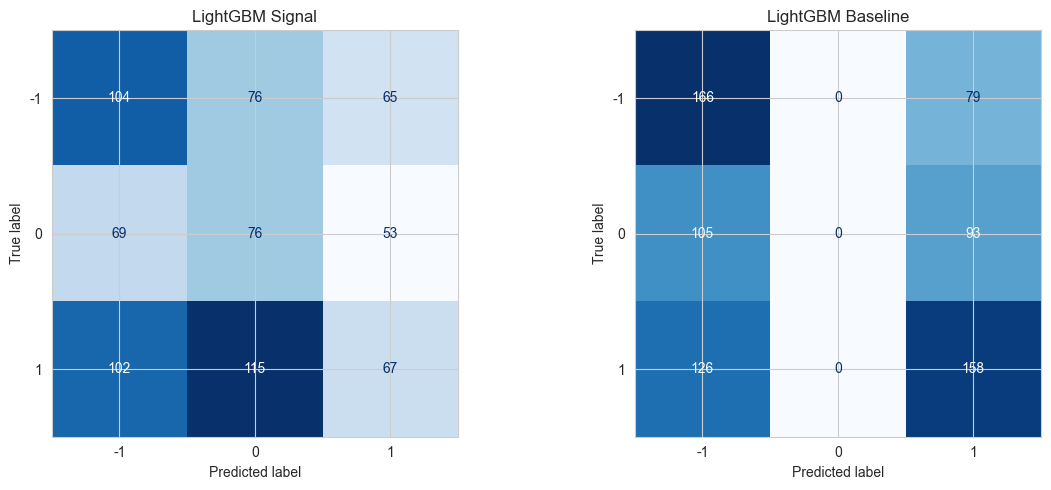

In [59]:
print("Generating Confusion Matrices...\n")

models_to_evaluate = {}

if 'signal_best_lgbm' in locals() and signal_best_lgbm is not None:
    models_to_evaluate['LightGBM Signal'] = (
        signal_best_lgbm,
        test_signal_features  # features created in the signal-model prep cell
    )

if 'baseline_best_lgbm' in locals() and baseline_best_lgbm is not None:
    models_to_evaluate['LightGBM Baseline'] = (
        baseline_best_lgbm,
        test_baseline_features  # ['day_ahead_price', 'spot_price']
    )

if 'best_xgb_model_selection' in locals() and best_xgb_model_selection is not None:
    print("Skipping XGBoost confusion matrix: binary forecasts are not comparable to 3-class targets.")

if models_to_evaluate:
    X_test_eval = test_df.drop(columns=[TARGET_COLUMN])
    y_test_eval = test_df[TARGET_COLUMN]
    plot_confusion_matrices(
        models_to_evaluate,
        y_test_eval,
        class_labels=[-1, 0, 1],
        label_encoder=label_encoder
    )
else:
    print("⚠ No models available for confusion matrix analysis")

## 🔬 Statistical Significance Testing
Rigorous statistical tests to validate model improvements.

In [60]:
print("Performing Statistical Significance Testing...\n")

if 'signal_best_lgbm' in locals() and 'baseline_best_lgbm' in locals():
    if signal_best_lgbm is not None and baseline_best_lgbm is not None:
        y_test_eval = test_signal_target  # or test_df[TARGET_COLUMN] if already aligned

        # use the feature sets each model trained on
        X_test_signal = test_signal_features
        X_test_baseline = test_baseline_features

        signal_pred_encoded = signal_best_lgbm.predict(X_test_signal)
        baseline_pred_encoded = baseline_best_lgbm.predict(X_test_baseline)

        try:
            signal_proba = signal_best_lgbm.predict_proba(X_test_signal)
        except LightGBMError:
            signal_proba = None

        try:
            baseline_proba = baseline_best_lgbm.predict_proba(X_test_baseline)
        except LightGBMError:
            baseline_proba = None

        signal_predictions = label_encoder.inverse_transform(signal_pred_encoded)
        baseline_predictions = label_encoder.inverse_transform(baseline_pred_encoded)

        statistical_results = compare_models_statistically(
            y_test_eval,
            signal_predictions,
            baseline_predictions,
            signal_proba=signal_proba,
            baseline_proba=baseline_proba
        )

        print("\nStatistical test results saved to 'statistical_results' variable")
    else:
        print("⚠ One or both LightGBM models are None")
else:
    print("⚠ Both signal and baseline models needed for statistical comparison")

Performing Statistical Significance Testing...


STATISTICAL MODEL COMPARISON

Signal accuracy:   0.3398
Baseline accuracy: 0.4457

1. McNemar's Test (Paired Model Comparison)
----------------------------------------------------------------------
Both models correct:       113
Only signal correct:       134
Only baseline correct:     211
Both models wrong:         269

Signal model correct:      247
Baseline model correct:    324

McNemar's χ² statistic:    16.7420
p-value:                   0.0000

✓ Signal model is HIGHLY SIGNIFICANTLY better (p < 0.001) ***


2. Bootstrap 95% Confidence Intervals for Accuracy
----------------------------------------------------------------------
Signal model:   0.3395 [0.3067, 0.3769]
Baseline model: 0.4462 [0.4099, 0.4856]
Difference:     -0.1068

✗ Baseline appears better (confidence intervals do not overlap)



Statistical test results saved to 'statistical_results' variable


,Accuracy,Macro-F1,AUC (macro)
Model,,,
LightGBM Signal (with news),0.339752,0.337532,0.511374
LightGBM Baseline (price-only),0.445667,0.343931,0.552642


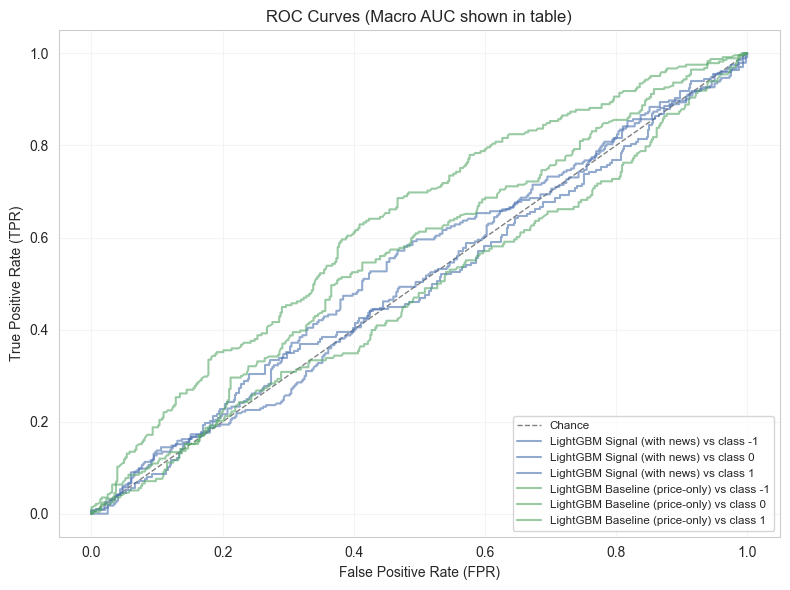


Classification report (signal model):
              precision    recall  f1-score   support

          -1       0.38      0.42      0.40       245
           0       0.28      0.38      0.33       198
           1       0.36      0.24      0.29       284

    accuracy                           0.34       727
   macro avg       0.34      0.35      0.34       727
weighted avg       0.35      0.34      0.34       727



,Total Return,Average Return,Volatility,Sharpe (annualised),Max Drawdown
Strategy,,,,,
LightGBM Signal,1357.09,1.866699,16.171186,10.803996,-494.93
LightGBM Baseline,6805.20,9.360660,18.322813,47.815244,-136.93
Naive Buy-DA/Sell-Spot,1044.42,1.436616,20.528065,6.550053,-1399.64


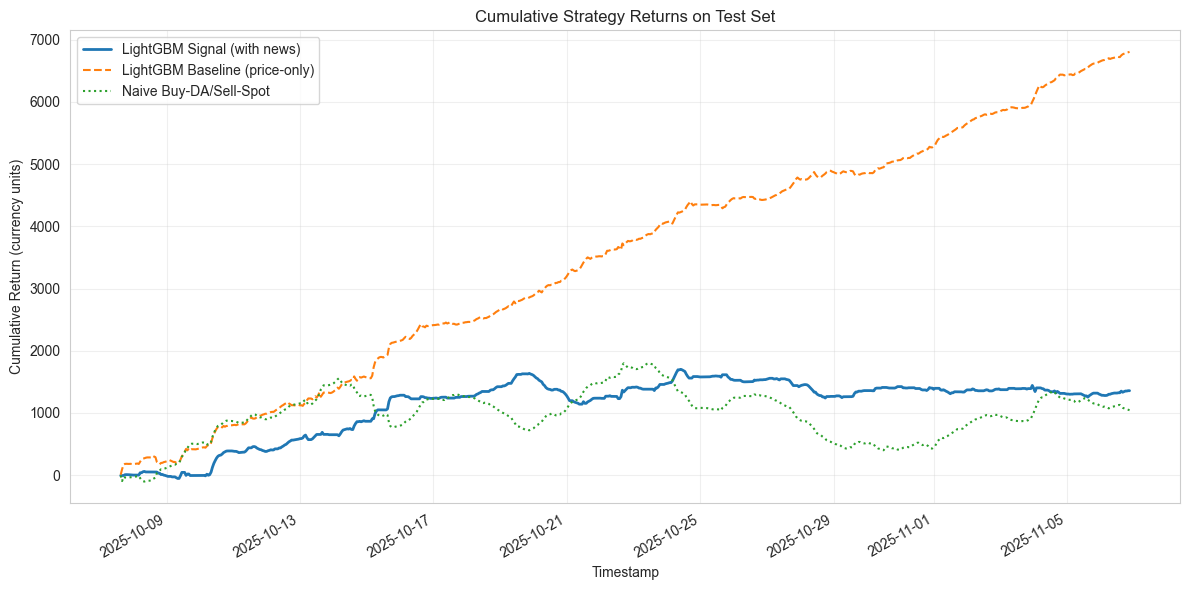

In [61]:
# Evaluate tuned decision model vs baseline and naive strategy on the test set
y_test_encoded = label_encoder.transform(test_signal_target)

signal_test_pred = signal_best_lgbm.predict(test_signal_features)
signal_test_proba = signal_best_lgbm.predict_proba(test_signal_features)

baseline_test_pred = baseline_best_lgbm.predict(test_baseline_features)
baseline_test_proba = baseline_best_lgbm.predict_proba(test_baseline_features)


def _safe_multiclass_auc(y_true: np.ndarray, proba: np.ndarray) -> float:
    unique_classes = np.unique(y_true)
    if unique_classes.size <= 1:
        return np.nan
    if unique_classes.size == 2:
        # Reduce to binary ROC AUC using the higher label as the positive class
        positive_class = unique_classes.max()
        proba_binary = proba[:, positive_class]
        y_binary = (y_true == positive_class).astype(int)
        return roc_auc_score(y_binary, proba_binary)
    proba_aligned = proba[:, unique_classes]
    return roc_auc_score(
        y_true,
        proba_aligned,
        multi_class='ovo',
        average='macro',
        labels=unique_classes
    )

# Classification metrics
signal_metrics = {
    'Model': 'LightGBM Signal (with news)',
    'Accuracy': accuracy_score(y_test_encoded, signal_test_pred),
    'Macro-F1': f1_score(y_test_encoded, signal_test_pred, average='macro', zero_division=0),
    'AUC (macro)': _safe_multiclass_auc(y_test_encoded, signal_test_proba)
}

baseline_metrics = {
    'Model': 'LightGBM Baseline (price-only)',
    'Accuracy': accuracy_score(y_test_encoded, baseline_test_pred),
    'Macro-F1': f1_score(y_test_encoded, baseline_test_pred, average='macro', zero_division=0),
    'AUC (macro)': _safe_multiclass_auc(y_test_encoded, baseline_test_proba)
}

metrics_df = pd.DataFrame([signal_metrics, baseline_metrics]).set_index('Model')
display(metrics_df)

auc_series = metrics_df['AUC (macro)'].dropna()
observed_labels = np.unique(y_test_encoded)
if observed_labels.size >= 2 and not auc_series.empty:
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1, label='Chance')

    model_curves = [
        (signal_test_proba, 'LightGBM Signal (with news)', '#4C72B0'),
        (baseline_test_proba, 'LightGBM Baseline (price-only)', '#55A868')
    ]

    if observed_labels.size == 2:
        positive_class = observed_labels.max()
        y_binary = (y_test_encoded == positive_class).astype(int)
        for proba, label, color in model_curves:
            fpr, tpr, _ = roc_curve(y_binary, proba[:, positive_class])
            ax.plot(fpr, tpr, label=f'{label}', color=color, linewidth=2)
    else:
        y_binarised = label_binarize(y_test_encoded, classes=observed_labels)
        for proba, label, color in model_curves:
            for idx, cls in enumerate(observed_labels):
                fpr, tpr, _ = roc_curve(y_binarised[:, idx], proba[:, cls])
                ax.plot(fpr, tpr, label=f'{label} vs class {label_encoder.inverse_transform([cls])[0]}', color=color, linewidth=1.5, alpha=0.6)

    ax.set_title('ROC Curves (Macro AUC shown in table)')
    ax.set_xlabel('False Positive Rate (FPR)')
    ax.set_ylabel('True Positive Rate (TPR)')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='lower right', fontsize='small')
    fig.tight_layout()
    plt.show()

print("\nClassification report (signal model):")
print(
    classification_report(
        y_test_encoded,
        signal_test_pred,
        labels=observed_labels,
        target_names=[str(cls) for cls in label_encoder.inverse_transform(observed_labels)]
    )
)

# Trading performance metrics
spot_series = test_df[SPOT_COL]
day_ahead_series = test_df[DAY_AHEAD_COL]
spread_series = spot_series - day_ahead_series

signal_actions = label_encoder.inverse_transform(signal_test_pred)
baseline_actions = label_encoder.inverse_transform(baseline_test_pred)
naive_actions = np.ones_like(signal_actions, dtype=int)


def actions_to_returns(actions: np.ndarray, spread: pd.Series) -> pd.Series:
    returns = np.where(actions == 1, spread, np.where(actions == -1, -spread, 0.0))
    return pd.Series(returns, index=spread.index)

signal_returns = actions_to_returns(signal_actions, spread_series)
baseline_returns = actions_to_returns(baseline_actions, spread_series)
naive_returns = actions_to_returns(naive_actions, spread_series)


def summarise_returns(returns: pd.Series, label: str) -> dict:
    cumulative = returns.cumsum()
    drawdown = cumulative - cumulative.cummax()
    mean_return = returns.mean()
    std_return = returns.std(ddof=1)
    periods_per_year = 24 * 365  # assume hourly cadence
    sharpe = (mean_return / std_return * np.sqrt(periods_per_year)) if std_return > 0 else np.nan
    return {
        'Strategy': label,
        'Total Return': cumulative.iloc[-1],
        'Average Return': mean_return,
        'Volatility': std_return,
        'Sharpe (annualised)': sharpe,
        'Max Drawdown': drawdown.min()
    }

returns_summary = pd.DataFrame([
    summarise_returns(signal_returns, 'LightGBM Signal'),
    summarise_returns(baseline_returns, 'LightGBM Baseline'),
    summarise_returns(naive_returns, 'Naive Buy-DA/Sell-Spot')
]).set_index('Strategy')

display(returns_summary)

# Plot cumulative returns comparison

def _prepare_plot_series(returns: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    cumulative = returns.cumsum()
    index = cumulative.index
    if isinstance(index, pd.DatetimeIndex):
        if index.tz is not None:
            index = index.tz_convert(None)
        x_values = index.to_pydatetime()
    else:
        x_values = np.arange(len(cumulative))
    return x_values, cumulative.to_numpy()

signal_x, signal_y = _prepare_plot_series(signal_returns)
baseline_x, baseline_y = _prepare_plot_series(baseline_returns)
naive_x, naive_y = _prepare_plot_series(naive_returns)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(signal_x, signal_y, '-', label='LightGBM Signal (with news)', linewidth=2)
ax.plot(baseline_x, baseline_y, '--', label='LightGBM Baseline (price-only)')
ax.plot(naive_x, naive_y, ':', label='Naive Buy-DA/Sell-Spot')
ax.set_title('Cumulative Strategy Returns on Test Set')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Cumulative Return (currency units)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# Store artifacts for downstream analysis
evaluation_artifacts = {
    'classification_metrics': metrics_df,
    'returns_summary': returns_summary,
    'signal_returns': signal_returns,
    'baseline_returns': baseline_returns,
    'naive_returns': naive_returns,
    'signal_actions': signal_actions,
    'baseline_actions': baseline_actions,
    'naive_actions': naive_actions
}


Analyzing LightGBM feature importance…

=== Signal Model ===


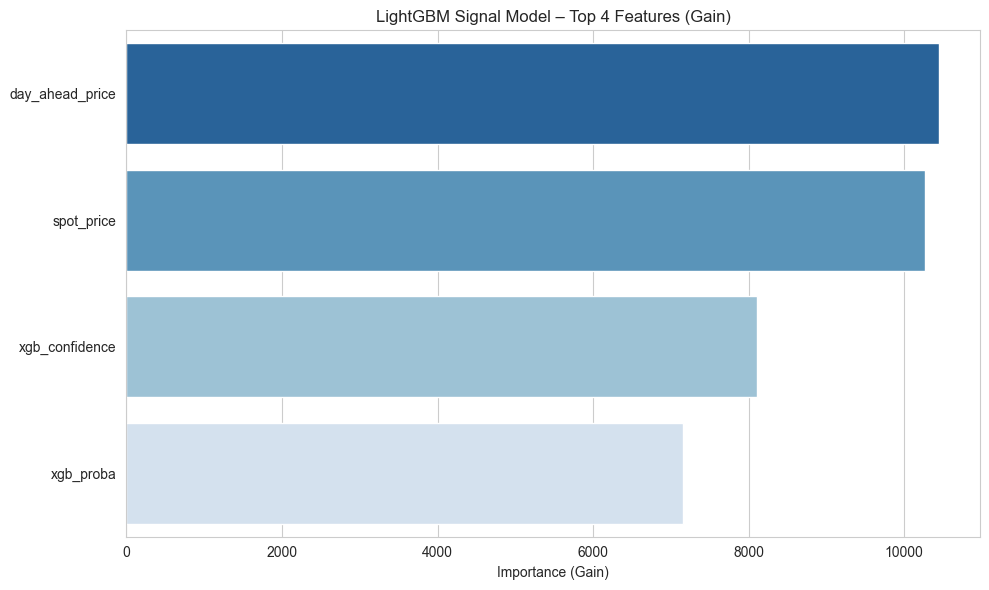


=== Baseline Model ===


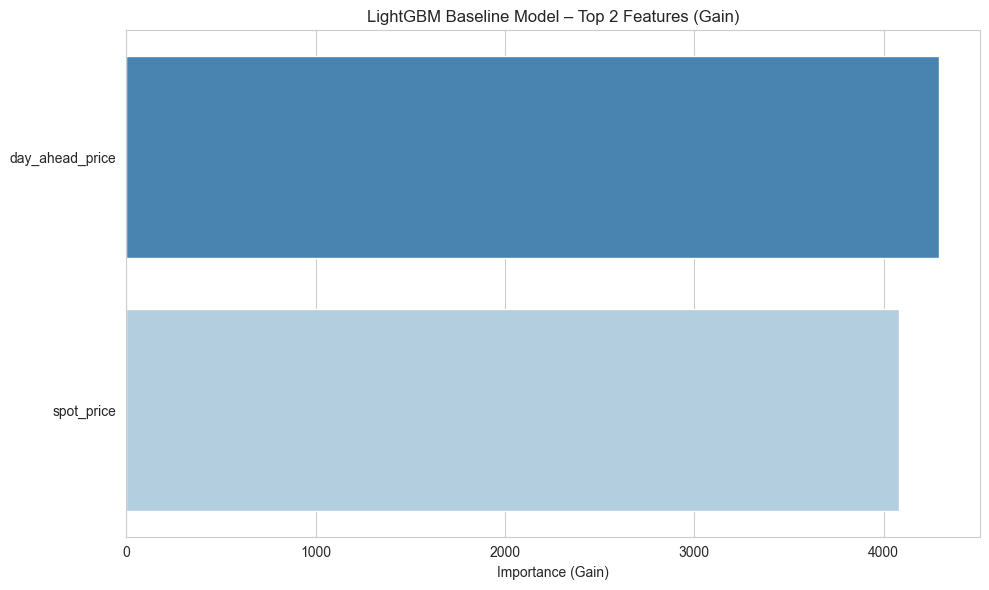

In [62]:
print("Analyzing LightGBM feature importance…\n")

# Signal model (trained on train_signal_features)
if 'signal_best_lgbm' in locals() and signal_best_lgbm is not None:
    print("=== Signal Model ===")
    signal_feature_cols = list(train_signal_features.columns)
    signal_importance_df = plot_feature_importance(
        signal_best_lgbm,
        signal_feature_cols,
        model_name='LightGBM Signal Model',
        top_n=20
    )
else:
    print("Signal model artifacts not available.\n")

# Baseline model (trained on baseline feature subset)
if 'baseline_best_lgbm' in locals() and baseline_best_lgbm is not None:
    print("\n=== Baseline Model ===")
    baseline_feature_cols = list(test_baseline_features.columns)
    baseline_importance_df = plot_feature_importance(
        baseline_best_lgbm,
        baseline_feature_cols,
        model_name='LightGBM Baseline Model',
        top_n=20
    )
else:
    print("\nBaseline model artifacts not available.")

In [63]:
# Analyze XGBoost feature importance
if 'best_xgb_model_selection' in locals() and best_xgb_model_selection is not None:
    print("\nAnalyzing XGBoost Model Feature Importance...")
    feature_cols = [col for col in train_df.columns if col != TARGET_COLUMN]
    xgb_importance = plot_feature_importance(
        best_xgb_model_selection,
        feature_cols,
        'XGBoost Model',
        top_n=20
    )



Analyzing XGBoost Model Feature Importance...
XGBoost Model does not expose feature_importances_.
